<a id="sec-01"></a>
# Pairs Trading and Statistical Arbitrage Backtester

**Large-cap US financials, 2007 to 2026. Walk-forward Engle-Granger pair selection, Ornstein-Uhlenbeck half-life filtering, and a z-score long-short backtest with per-leg transaction costs.**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Avinashmhm/QuantProjects/blob/main/Pairs%20Trading/pairs_trading_stat_arb_backtester.ipynb)

**Abstract.** Can a market-neutral pairs strategy extract a tradable, mean-reverting signal from a sector of closely related stocks, and does that signal survive out-of-sample testing and realistic transaction costs? This notebook screens all 66 pairs of 12 large-cap US financial stocks for cointegration with the Engle-Granger two-step test, models each surviving spread as an Ornstein-Uhlenbeck process, filters on the estimated half-life of mean reversion, and trades z-score entry/exit signals dollar for dollar, long one leg and short the other. Pair selection and every parameter (hedge ratio, spread mean, spread volatility) are estimated on a rolling 24-month formation window and then applied to the following 6-month trading window, so all headline results are strictly out of sample. Costs are charged per leg on every trade, and gross and net results are shown side by side against SPY and an equal-weight bank basket. Out of sample from January 2009 to June 2026 the strategy earns a 3.0% CAGR at 4.8% volatility net of costs (Sharpe 0.64, Newey-West t = 2.81) with a SPY beta of -0.01 and a -10.4% maximum drawdown: a statistically significant but modest edge, concentrated in the 2009-2012 recovery. The headline exhibit and every reported statistic come from the concatenated out-of-sample windows only; a circular in-sample version is shown once, as a warning about selection leakage.

**What you'll see:** cointegration screening with a multiple-testing correction, an OU half-life derivation and filter, spread and z-score charts with trade markers, an out-of-sample equity curve versus SPY, a rolling cointegration p-value, gross-versus-net cost analysis, per-pair attribution, and a beta-to-SPY significance test.

<a id="toc"></a>
## Table of Contents

1. [Title and Abstract](#sec-01)
2. [Table of Contents](#toc)
3. [Real-World Use Case and System Architecture](#sec-03)
4. [Environment Setup](#sec-04)
5. [Secrets and API Keys](#sec-05)
6. [Data Acquisition Pipeline](#sec-06)
7. [Data Validation and Cleaning](#sec-07)
8. [Feature Engineering](#sec-08)
9. [Exploratory Data Analysis](#sec-09)
10. [Methodology](#sec-10)
11. [Core Implementation](#sec-11)
12. [Validation and Statistical Rigor](#sec-12)
13. [Results and Performance Metrics](#sec-13)
14. [Visualization Suite and Dashboard](#sec-14)
15. [Robustness and Sensitivity](#sec-15)
16. [Limitations and Assumptions](#sec-16)
17. [Conclusion, Extensions and Deliverables](#sec-17)
18. [References](#sec-18)
19. [README and Resume Bullets](#sec-19)
20. [Final Summary](#sec-20)

<a id="sec-03"></a>
## 3. Real-World Use Case and System Architecture

Market-neutral statistical arbitrage is the core franchise of multi-strategy funds such as Citadel, Millennium, and Point72. A stat-arb desk does not run one pair; it runs thousands of small, mutually offsetting spread positions whose individual edges are tiny but whose aggregate, after netting, produces a return stream with near-zero market beta. Pairs trading is the canonical entry point to that business: it forces you to find a *stationary* signal (a spread that reverts to a mean) rather than a directional bet, to size positions so the market factor cancels, and to confront the two things that kill most stat-arb backtests in practice: selection bias and transaction costs.

The pipeline in this notebook mirrors how a desk would structure the research version of such a system:

```
+------------------+     +--------------------+     +----------------------+
|  DATA            |     |  FORMATION         |     |  TRADING             |
|  Yahoo Finance   | --> |  (24m rolling)     | --> |  (next 6m, OOS)      |
|  12 banks + SPY  |     |  - Engle-Granger   |     |  - frozen beta,mu,sd |
|  daily adj close |     |    on all 66 pairs |     |  - z-score signals   |
+------------------+     |  - multiple-test   |     |  - enter |z| > 2     |
                         |    threshold       |     |  - exit  |z| < 0.5   |
                         |  - OU half-life    |     |  - stop  |z| > 3     |
                         |    filter (5-60d)  |     |  - per-leg costs     |
                         +--------------------+     +----------+-----------+
                                                               |
                         +--------------------+     +----------v-----------+
                         |  REPORTING         |     |  EVALUATION          |
                         |  - tear sheet      | <-- |  - concat OOS P&L    |
                         |  - hero dashboard  |     |  - Newey-West t-stat |
                         |  - trades CSV      |     |  - beta-to-SPY test  |
                         |  - README bullets  |     |  - benchmarks        |
                         +--------------------+     +----------------------+
```

Everything below lives in one Colab notebook for portability, but the code is organized the way a standalone repository would be:

```
pairs-trading-stat-arb/
  data/               cached price downloads (auto-created, gitignored)
  src/
    data.py           fetch pipeline with cache, retries, synthetic fallback
    cointegration.py  Engle-Granger screen, OU half-life fit
    signals.py        z-score state machine (entry / exit / stop / lockout)
    backtest.py       walk-forward engine, cost model, trade ledger
    metrics.py        performance and risk statistics
    plots.py          house-styled chart suite
  notebooks/
    pairs_trading_stat_arb_backtester.ipynb   this file
  outputs/            figures, tables, trade ledger (auto-created)
  requirements.txt
  README.md
```

<a id="sec-04"></a>
## 4. Environment Setup

One pinned install cell (skipped when the environment already has the packages or when running offline), then all imports, seeds, display options, the plotting theme, and a single `CONFIG` dict that holds every tunable parameter in the notebook. No magic numbers appear downstream; anything you might want to change lives here.

In [1]:
import importlib.util
import os
import subprocess
import sys

PINNED = {"yfinance": "yfinance==1.2.0", "kaleido": "kaleido==0.2.1"}
missing = [spec for mod, spec in PINNED.items() if importlib.util.find_spec(mod) is None]

if missing and not os.environ.get("QUANT_OFFLINE"):
    print("Installing:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    mode = " (offline mode: installs skipped)" if os.environ.get("QUANT_OFFLINE") else ""
    print(f"Environment ready{mode}. Missing-but-skipped: {missing or 'none'}")

Environment ready. Missing-but-skipped: none


In [2]:
from __future__ import annotations

import itertools
import os
import random
import sys
import time
import warnings
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from matplotlib.ticker import PercentFormatter
from statsmodels.tsa.stattools import adfuller, coint
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 30)

# Monthly resample alias: pandas 2.2+ uses "ME", older versions use "M".
MONTH_END = "ME" if tuple(int(x) for x in pd.__version__.split(".")[:2]) >= (2, 2) else "M"

print(f"numpy {np.__version__} | pandas {pd.__version__} | "
      f"statsmodels {sm.__version__} | seed {SEED} | month alias '{MONTH_END}'")

numpy 1.26.4 | pandas 2.1.4 | statsmodels 0.14.1 | seed 42 | month alias 'M'


In [3]:
# House chart theme: one palette and one style for every figure in the notebook.
PALETTE = {
    "strategy": "#1f4e79", "gross": "#5b8ac5", "benchmark": "#9aa3ad",
    "basket": "#7a6a8a", "positive": "#2e7d32", "negative": "#c62828",
    "accent": "#e8833a", "neutral": "#4f5b66", "band": "#d9c89e",
}
SOURCE_NOTE = "Pairs Trading Backtester | data: Yahoo Finance (adj. close)"


def set_house_theme() -> None:
    """Apply the house matplotlib/seaborn style used by every chart below."""
    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white",
        "axes.facecolor": "white", "axes.titlesize": 12, "axes.titleweight": "bold",
        "axes.labelsize": 10, "axes.edgecolor": "#444444", "font.size": 10,
        "legend.frameon": False, "lines.linewidth": 1.6,
    })


set_house_theme()

TRADING_DAYS_PER_YEAR = 252

CONFIG = {
    # Universe and sample. END is pinned so re-runs reproduce the same numbers.
    "TICKERS": ["JPM", "BAC", "WFC", "C", "GS", "MS",
                "USB", "PNC", "TFC", "SCHW", "COF", "STT"],
    "BENCHMARK": "SPY",
    "START": "2007-01-01",
    "END": "2026-06-30",

    # Walk-forward geometry, in trading days.
    "FORMATION_DAYS": 504,   # 24 months: estimate cointegration, beta, mu, sigma
    "TRADE_DAYS": 126,       # 6 months: trade with frozen parameters, then roll

    # Pair-selection filters, applied on the formation window only.
    "EG_PVALUE_MAX": 0.01,   # stricter than 0.05 to control 66-way multiple testing
    "HALF_LIFE_MIN": 5.0,    # days; faster reversion than this is eaten by costs
    "HALF_LIFE_MAX": 60.0,   # days; slower ties up capital and reverts unreliably
    "BETA_MIN": 0.4,         # hedge-ratio hygiene: keep legs comparable in size
    "BETA_MAX": 2.5,
    "MAX_PAIRS": 5,          # capital is split equally across selected pairs

    # Signal thresholds in z-score units.
    "ENTRY_Z": 2.0,
    "EXIT_Z": 0.5,
    "STOP_Z": 3.0,

    # Frictions: one-way cost per leg (commission + half-spread + slippage).
    "COST_PER_LEG_BPS": 5.0,

    # Reporting.
    "ROLL_SHARPE_WIN": 126,
    "SEED": SEED,
}

print(f"Universe: {len(CONFIG['TICKERS'])} tickers -> "
      f"{len(CONFIG['TICKERS']) * (len(CONFIG['TICKERS']) - 1) // 2} candidate pairs | "
      f"benchmark {CONFIG['BENCHMARK']} | {CONFIG['START']} to {CONFIG['END']}")

Universe: 12 tickers -> 66 candidate pairs | benchmark SPY | 2007-01-01 to 2026-06-30


<a id="sec-05"></a>
## 5. Secrets and API Keys

This project needs **no API key at all**: Yahoo Finance via `yfinance` is free and unauthenticated. The cell below still sets up the house key-resolution pattern (Colab `userdata`, then environment variable, then an interactive prompt only when a terminal is attached) so the notebook is a template for projects that do need keys, and it prints which data path will be used. If every network path fails, the notebook falls back to a clearly labeled synthetic dataset so it always runs end to end. Setting the environment variable `QUANT_OFFLINE=1` forces that synthetic path deterministically.

In [4]:
def in_colab() -> bool:
    """True when running inside Google Colab (import guarded for other hosts)."""
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def resolve_secret(name: str) -> Optional[str]:
    """Resolve an API key without ever blocking a headless run.

    Order: Colab userdata -> environment variable -> getpass (TTY only) -> None.
    """
    if IN_COLAB:
        try:
            from google.colab import userdata
            val = userdata.get(name)
            if val:
                return val
        except Exception:
            pass
    if os.environ.get(name):
        return os.environ[name]
    if sys.stdin.isatty():
        try:
            import getpass
            return getpass.getpass(f"{name} (press Enter to skip): ") or None
        except Exception:
            return None
    return None


IN_COLAB = in_colab()
OFFLINE = bool(os.environ.get("QUANT_OFFLINE"))
OUTPUT_DIR = os.environ.get("QUANT_OUTPUT_DIR") or ("/content" if IN_COLAB else "outputs")
CACHE_DIR = os.path.join(OUTPUT_DIR, ".quant_cache")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

data_path = "SYNTHETIC (QUANT_OFFLINE=1)" if OFFLINE else "LIVE Yahoo Finance (no key required)"
print(f"Colab: {IN_COLAB} | offline: {OFFLINE} | data path: {data_path}")
print(f"Outputs -> {OUTPUT_DIR} | cache -> {CACHE_DIR}")

Colab: False | offline: False | data path: LIVE Yahoo Finance (no key required)
Outputs -> /Users/avinashmahadevan/Desktop/CC/quantprojects/outputs | cache -> /Users/avinashmahadevan/Desktop/CC/quantprojects/outputs/.quant_cache


<a id="sec-06"></a>
## 6. Data Acquisition Pipeline

**Source.** Daily adjusted close prices from Yahoo Finance via `yfinance` (splits and dividends folded in via `auto_adjust=True`), for 12 large-cap US financials and SPY, 2007-01-01 to 2026-06-30. Daily frequency, close-to-close. One universe note: BNY Mellon (BK) was originally slated for this list, but Yahoo currently returns no usable price history for that symbol, so State Street (STT), the closest business match as the other large US custody bank, takes its place.

**Survivorship caveat, stated up front.** The universe is today's surviving large-cap financials. Firms that failed or were absorbed in the crisis (Lehman Brothers, Wachovia, Washington Mutual, National City, Countrywide) are absent, which makes the 2007-2009 stretch look calmer and more tradable than it was. A pair containing Lehman would have produced a catastrophic non-reverting spread in 2008; nothing in this dataset can reproduce that. Section 16 quantifies the direction of this bias. Yahoo data is also not point-in-time: adjusted prices are restated by later corporate actions.

**Pipeline contract.** One reusable fetcher with local caching (no re-download on re-run), three retries with backoff, and a deterministic, clearly labeled synthetic fallback so the notebook always runs end to end, even fully offline. The synthetic generator is built for this project: it plants genuine cointegration (groups of names share a common stochastic trend, with stationary Ornstein-Uhlenbeck deviations), so the screening logic downstream has something real to find in offline mode. A provenance summary prints after every load.

In [5]:
def synth_bank_universe(tickers: List[str], benchmark: str, start: str, end: str,
                        seed: int = SEED) -> pd.DataFrame:
    """Deterministic synthetic price panel with genuine cointegration planted in it.

    Names are split into 4 groups. Each group shares one non-stationary log-price
    trend (a random walk that loads on a common market factor); each name is that
    trend times a loading, plus a stationary Ornstein-Uhlenbeck deviation. Within a
    group, any two names are cointegrated by construction (the shared trend cancels
    at the loading ratio); across groups they are not. The benchmark tracks the
    market factor. Clearly labeled SYNTHETIC wherever it is used.
    """
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start, end)
    n = len(dates)
    n_groups = 4

    mkt = np.cumsum(rng.normal(0.00030, 0.011, n))
    group_trends = [0.9 * mkt + np.cumsum(rng.normal(0.0, 0.009, n))
                    for _ in range(n_groups)]
    loadings = [0.85, 1.00, 1.15]

    out = {}
    for i, tkr in enumerate(tickers):
        g, tier = i % n_groups, i // n_groups
        half_life = 8.0 + 37.0 * i / max(1, len(tickers) - 1)   # 8 to 45 days
        theta = np.log(2.0) / half_life
        ou = np.empty(n)
        ou[0] = 0.0
        shocks = rng.normal(0.0, 0.0055, n)
        for t in range(1, n):
            ou[t] = (1.0 - theta) * ou[t - 1] + shocks[t]
        log_px = np.log(80.0 + 5.0 * i) + loadings[tier % 3] * group_trends[g] + ou
        out[tkr] = np.exp(log_px)
    out[benchmark] = np.exp(np.log(150.0) + mkt)
    return pd.DataFrame(out, index=dates)


def _print_provenance(df: pd.DataFrame, source: str, note: str = "") -> None:
    """Standard provenance block: source, rows, range, frequency."""
    print("--- data provenance ---")
    print(f"source    : {source}")
    print(f"rows      : {df.shape[0]:,}   cols: {df.shape[1]}   freq: daily")
    print(f"range     : {df.index.min().date()} -> {df.index.max().date()}")
    if note:
        print(f"note      : {note}")


def fetch_prices(tickers: List[str], start: str, end: str,
                 retries: int = 3) -> pd.DataFrame:
    """Adjusted-close panel: offline -> cache -> live Yahoo -> synthetic fallback.

    Returns the RAW panel (may contain NaNs); cleaning happens, visibly, in the
    validation section so before/after can be shown.
    """
    if OFFLINE:
        df = synth_bank_universe(tickers[:-1], tickers[-1], start, end)
        _print_provenance(df, "SYNTHETIC (QUANT_OFFLINE=1)",
                          "planted cointegration; NOT real prices")
        return df

    cache_key = f"prices_{'_'.join(tickers)}_{start}_{end}".replace("/", "-")
    cache_file = os.path.join(CACHE_DIR, f"{cache_key}.pkl")
    if os.path.exists(cache_file):
        df = pd.read_pickle(cache_file)
        _print_provenance(df, "CACHE (Yahoo Finance)", "loaded from local cache")
        return df

    for attempt in range(retries):
        try:
            import yfinance as yf
            raw = yf.download(tickers, start=start, end=end, auto_adjust=True,
                              progress=False)["Close"]
            if isinstance(raw, pd.Series):
                raw = raw.to_frame(tickers[0])
            raw = raw[tickers]
            if raw.dropna(how="all").shape[0] > 250:
                raw.to_pickle(cache_file)
                _print_provenance(raw, "LIVE Yahoo Finance",
                                  "adjusted close (splits+dividends); survivorship-biased universe")
                return raw
            raise ValueError(f"download too short: {raw.shape}")
        except Exception as exc:
            print(f"  [fetch_prices] attempt {attempt + 1}/{retries} failed: {exc}")
            time.sleep(1.0 * (attempt + 1))

    df = synth_bank_universe(tickers[:-1], tickers[-1], start, end)
    _print_provenance(df, "SYNTHETIC (live fetch unavailable)",
                      "planted cointegration; NOT real prices")
    return df


ALL_TICKERS = CONFIG["TICKERS"] + [CONFIG["BENCHMARK"]]
prices_raw = fetch_prices(ALL_TICKERS, CONFIG["START"], CONFIG["END"])
DATA_IS_SYNTHETIC = OFFLINE or prices_raw.shape[0] == len(pd.bdate_range(CONFIG["START"], CONFIG["END"]))
print(f"\nData mode: {'SYNTHETIC' if DATA_IS_SYNTHETIC else 'REAL (Yahoo Finance)'}")

--- data provenance ---
source    : CACHE (Yahoo Finance)
rows      : 4,902   cols: 13   freq: daily
range     : 2007-01-03 -> 2026-06-29
note      : loaded from local cache

Data mode: REAL (Yahoo Finance)


<a id="sec-07"></a>
## 7. Data Validation and Cleaning

Before any modeling: check coverage per ticker, missing values, non-positive prices, duplicate dates, and outlier daily moves. Cleaning is deliberately minimal and leak-safe: sort by date, drop duplicate dates, forward-fill isolated gaps (a forward fill only carries *past* information forward, so it cannot leak the future), and drop leading rows where any ticker has not started trading. Any ticker whose history starts materially after 2007 would be dropped with a warning rather than silently backfilled; backfilling would pull future prices into the past. The cell asserts integrity at the end and prints a before/after summary.

In [6]:
def validate_and_clean(raw: pd.DataFrame, required_start: str = "2007-03-01"
                       ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Coverage report + leak-safe cleaning. Returns (clean_panel, coverage_table)."""
    rets_raw = raw.pct_change()
    coverage = pd.DataFrame({
        "first_valid": raw.apply(lambda s: s.first_valid_index()),
        "last_valid": raw.apply(lambda s: s.last_valid_index()),
        "n_obs": raw.notna().sum(),
        "n_missing": raw.isna().sum(),
        "max_abs_daily_move": rets_raw.abs().max(),
    })

    late = coverage[coverage["first_valid"].isna()
                    | (coverage["first_valid"] > pd.Timestamp(required_start))].index.tolist()
    keep = [t for t in raw.columns if t not in late]
    if late:
        print(f"WARNING: dropping tickers with history starting after {required_start}: {late}")

    clean = raw[keep].copy()
    clean = clean[~clean.index.duplicated(keep="first")].sort_index()
    clean = clean.ffill().dropna(how="any")

    assert clean.isna().sum().sum() == 0, "NaNs survived cleaning"
    assert (clean > 0).all().all(), "non-positive prices survived cleaning"
    assert clean.index.is_monotonic_increasing, "dates not sorted"
    return clean, coverage


prices_all, coverage = validate_and_clean(prices_raw)
print("Coverage by ticker:")
display(coverage)

biggest = (prices_all.pct_change().abs().stack()
           .sort_values(ascending=False).head(5))
print("\n5 largest absolute daily moves (ticker, date, |return|):")
for (dt, tkr), v in biggest.items():
    print(f"  {tkr:>5}  {dt.date()}  {v:6.1%}")

summary = pd.DataFrame({
    "rows": [prices_raw.shape[0], prices_all.shape[0]],
    "cols": [prices_raw.shape[1], prices_all.shape[1]],
    "NaNs": [int(prices_raw.isna().sum().sum()), 0],
    "start": [prices_raw.index.min().date(), prices_all.index.min().date()],
    "end": [prices_raw.index.max().date(), prices_all.index.max().date()],
}, index=["before cleaning", "after cleaning"])
print("\nBefore/after summary:")
display(summary)

BANKS = [t for t in CONFIG["TICKERS"] if t in prices_all.columns]
PRICES = prices_all[BANKS]
BENCH_PX = prices_all[CONFIG["BENCHMARK"]]
N_PAIRS_TOTAL = len(BANKS) * (len(BANKS) - 1) // 2
print(f"\nFinal universe: {len(BANKS)} banks -> {N_PAIRS_TOTAL} candidate pairs; "
      f"{prices_all.shape[0]:,} trading days")

Coverage by ticker:


,first_valid,last_valid,n_obs,n_missing,max_abs_daily_move
Ticker,,,,,
JPM,2007-01-03,2026-06-29,4902,0,0.250967
BAC,2007-01-03,2026-06-29,4902,0,0.352692
WFC,2007-01-03,2026-06-29,4902,0,0.327645
C,2007-01-03,2026-06-29,4902,0,0.578249
GS,2007-01-03,2026-06-29,4902,0,0.264678
MS,2007-01-03,2026-06-29,4902,0,0.869835
USB,2007-01-03,2026-06-29,4902,0,0.228412
PNC,2007-01-03,2026-06-29,4902,0,0.413959
TFC,2007-01-03,2026-06-29,4902,0,0.236126



5 largest absolute daily moves (ticker, date, |return|):
     MS  2008-10-13   87.0%
    STT  2009-01-20   59.0%
      C  2008-11-24   57.8%
    PNC  2009-01-20   41.4%
      C  2009-02-27   39.0%

Before/after summary:


,rows,cols,NaNs,start,end
before cleaning,4902,13,0,2007-01-03,2026-06-29
after cleaning,4902,13,0,2007-01-03,2026-06-29



Final universe: 12 banks -> 66 candidate pairs; 4,902 trading days


<a id="sec-08"></a>
## 8. Feature Engineering

Pairs trading needs only three primitive inputs, but the *timing discipline* around them is everything:

- **Log prices** $\ln P_t$: the cointegrating regression runs on logs, so the hedge ratio $\beta$ is the elasticity between the two names and the spread is a percentage-scale object, stable across price levels. A stock trading at \$300 and one at \$30 can be compared without the \$300 name dominating the fit.
- **Simple returns** $r_t = P_t/P_{t-1} - 1$: dollar P&L of a dollar position is a *simple* return quantity, so all backtest accounting uses simple returns. (Signals live in log space, P&L in simple-return space; the two are stated explicitly to avoid convention drift.)
- **Window-local spread parameters**: the hedge ratio $\beta$, spread mean $\mu$, and spread volatility $\sigma$ are *not* global features. Each is estimated on a formation window and applied, frozen, to the following trading window. Precomputing any of them over the full sample would be a look-ahead leak; that is why there is deliberately no global feature matrix in this notebook.

**The lag convention used everywhere:** a signal observed at the close of day $t$ can first earn (or lose) money on day $t{+}1$. In code, positions are shifted one day before being multiplied by returns. Every engine component below follows this convention, and Section 12 audits it.

The cell demonstrates the formation/trading split once, on a single example pair and window, so the mechanics are concrete before the full engine automates them.

In [7]:
LOG_PX = np.log(PRICES)
RETS = PRICES.pct_change().fillna(0.0)
BENCH_RET = BENCH_PX.pct_change().fillna(0.0)

# One concrete formation/trading split, as a preview of the engine.
form_days, trade_days = CONFIG["FORMATION_DAYS"], CONFIG["TRADE_DAYS"]
ex_a, ex_b = BANKS[0], BANKS[1]
form_slice = LOG_PX.iloc[:form_days]
trade_slice = LOG_PX.iloc[form_days:form_days + trade_days]

X = sm.add_constant(form_slice[ex_b])
ols = sm.OLS(form_slice[ex_a], X).fit()
alpha_ex, beta_ex = float(ols.params.iloc[0]), float(ols.params.iloc[1])
form_spread = form_slice[ex_a] - alpha_ex - beta_ex * form_slice[ex_b]
mu_ex, sigma_ex = float(form_spread.mean()), float(form_spread.std(ddof=1))

trade_spread = trade_slice[ex_a] - alpha_ex - beta_ex * trade_slice[ex_b]
trade_z = (trade_spread - mu_ex) / sigma_ex

assert form_slice.index.max() < trade_slice.index.min(), \
    "formation window must end before the trading window starts"
print(f"Example pair {ex_a}/{ex_b}:")
print(f"  formation {form_slice.index.min().date()} -> {form_slice.index.max().date()} "
      f"({form_days} days)")
print(f"  trading   {trade_slice.index.min().date()} -> {trade_slice.index.max().date()} "
      f"({len(trade_slice)} days)")
print(f"  frozen params: beta={beta_ex:.3f}  mu={mu_ex:.5f}  sigma={sigma_ex:.5f}")
print(f"  trading-window z-score range: [{trade_z.min():.2f}, {trade_z.max():.2f}]")
print("  Look-ahead check passed: parameters use formation data only.")

Example pair JPM/BAC:
  formation 2007-01-03 -> 2008-12-31 (504 days)
  trading   2009-01-02 -> 2009-07-02 (126 days)
  frozen params: beta=0.349  mu=-0.00000  sigma=0.05721
  trading-window z-score range: [-3.15, 5.29]
  Look-ahead check passed: parameters use formation data only.


<a id="sec-09"></a>
## 9. Exploratory Data Analysis

Three questions motivate the method. First, do bank stocks move together enough that spreads between them might be stable? (Look at the common rise and fall in levels, and the high return correlations.) Second, is correlation alone enough? No: two stocks can be 90% correlated day to day while their price *ratio* trends away forever. Cointegration, not correlation, is the property that makes a spread tradable, and the last chart shows the difference on this very dataset. Third, is cointegration widespread or rare among these 66 pairs? The p-value heatmap gives a first look.

**Rigor note:** the full-sample heatmap and the illustrative spreads below are for intuition only. The backtest never uses full-sample estimates; every tradable decision comes from rolling formation windows. This distinction is the entire point of Section 12.

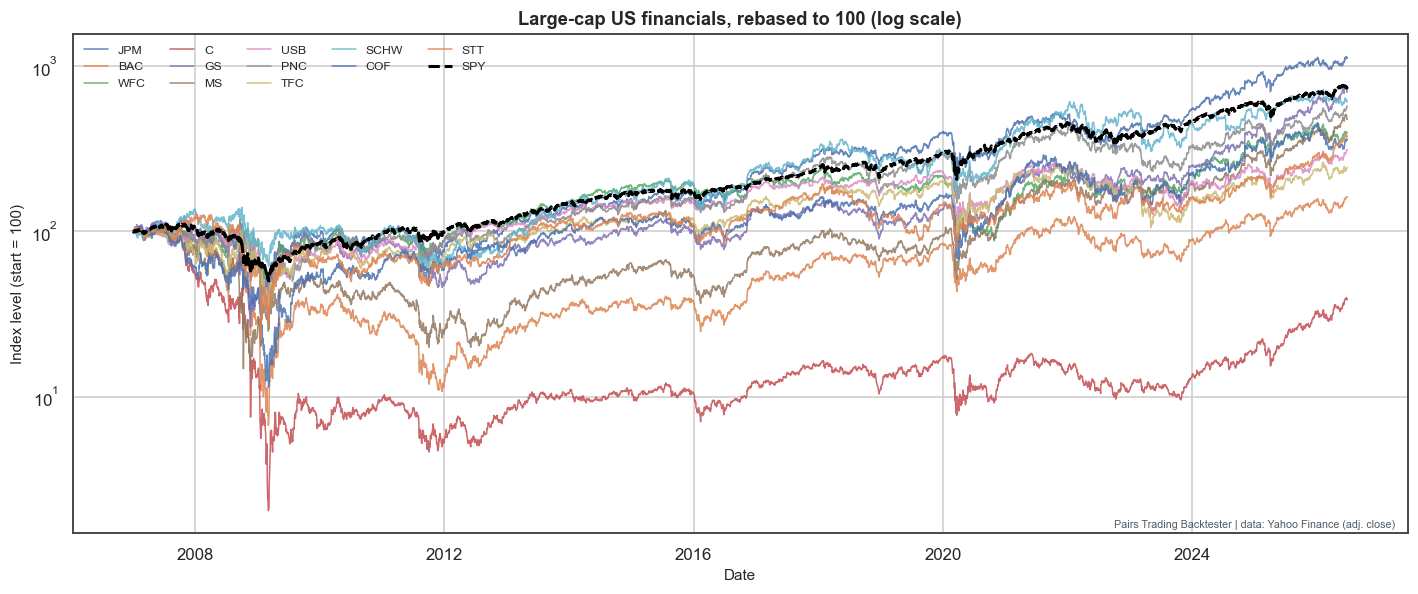

In [8]:
fig, ax = plt.subplots(figsize=(13, 5.5))
rebased = 100.0 * PRICES / PRICES.iloc[0]
for tkr in BANKS:
    ax.plot(rebased.index, rebased[tkr], lw=1.0, alpha=0.85, label=tkr)
bench_rb = 100.0 * BENCH_PX / BENCH_PX.iloc[0]
ax.plot(bench_rb.index, bench_rb, color="black", lw=2.0, ls="--",
        label=CONFIG["BENCHMARK"])
ax.set_yscale("log")
ax.set_title("Large-cap US financials, rebased to 100 (log scale)")
ax.set_ylabel("Index level (start = 100)")
ax.set_xlabel("Date")
ax.legend(ncol=5, fontsize=8, loc="upper left")
ax.annotate(SOURCE_NOTE, xy=(0.99, 0.01), xycoords="axes fraction",
            ha="right", fontsize=7, color=PALETTE["neutral"])
plt.tight_layout()
plt.show()

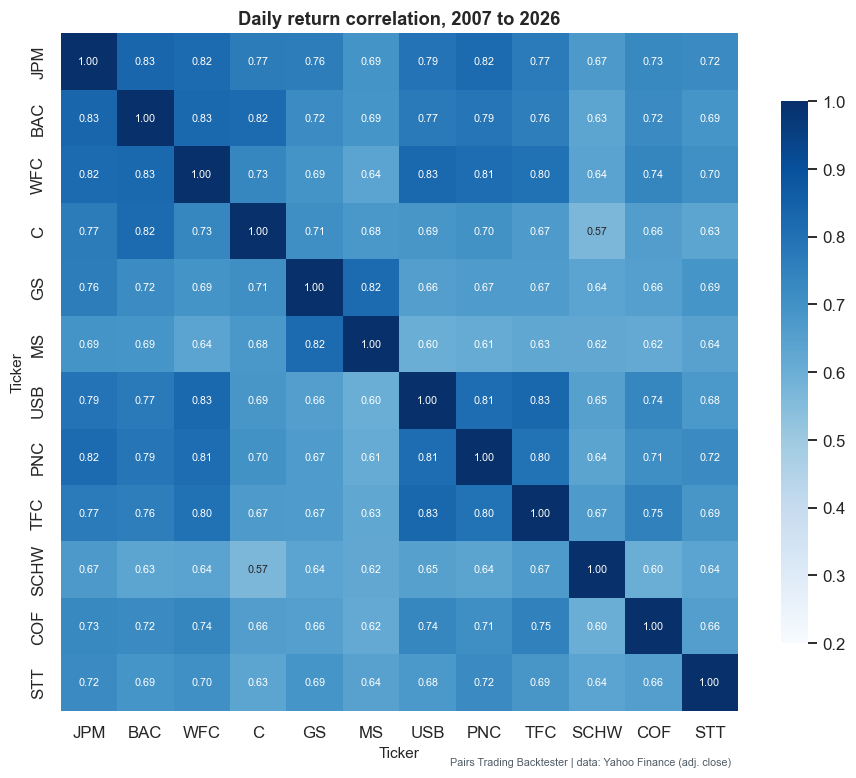

Average pairwise return correlation: 0.71 (high co-movement makes this sector a natural pairs universe)


In [9]:
fig, ax = plt.subplots(figsize=(8.5, 7))
corr = RETS[BANKS].corr()
sns.heatmap(corr, cmap="Blues", vmin=0.2, vmax=1.0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Daily return correlation, 2007 to 2026")
ax.annotate(SOURCE_NOTE, xy=(0.99, -0.08), xycoords="axes fraction",
            ha="right", fontsize=7, color=PALETTE["neutral"])
plt.tight_layout()
plt.show()

avg_corr = corr.values[np.triu_indices_from(corr.values, k=1)].mean()
print(f"Average pairwise return correlation: {avg_corr:.2f} "
      f"(high co-movement makes this sector a natural pairs universe)")

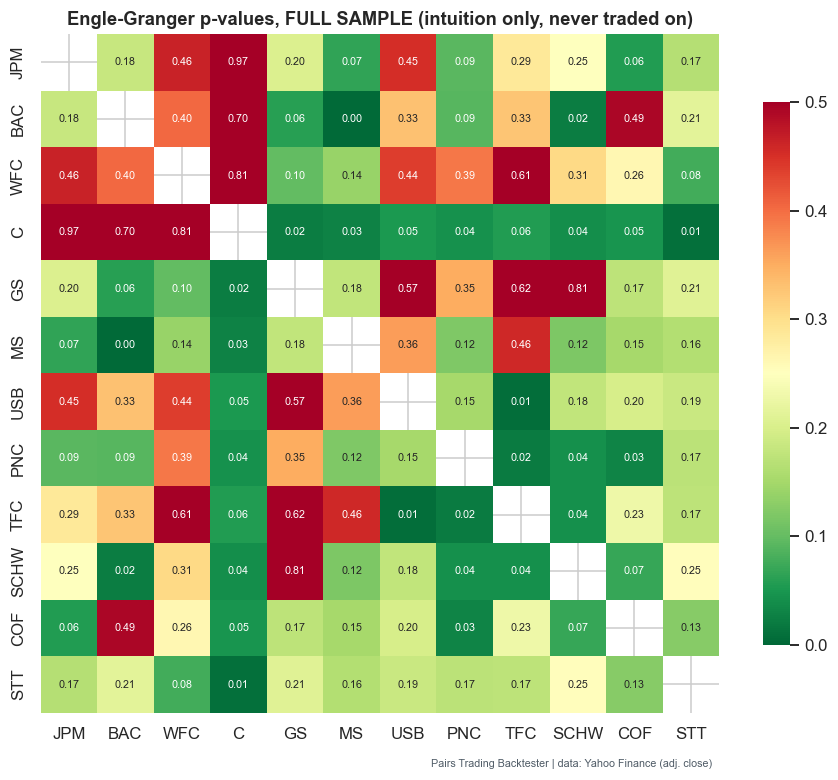

13 of 66 pairs have full-sample EG p < 0.05. At a 5% false-positive rate, ~3.3 could pass by luck alone; Section 10 addresses this multiple-testing problem.


In [10]:
def _eg_pvalue(log_y: pd.Series, log_x: pd.Series) -> float:
    """Engle-Granger cointegration p-value (statsmodels MacKinnon surface)."""
    return float(coint(log_y, log_x, trend="c")[1])


# Full-sample EG p-values for all pairs. INTUITION ONLY: the backtest never sees this.
pv_full = pd.DataFrame(np.nan, index=BANKS, columns=BANKS)
for a, b in itertools.combinations(BANKS, 2):
    p = _eg_pvalue(LOG_PX[a], LOG_PX[b])
    pv_full.loc[a, b] = p
    pv_full.loc[b, a] = p

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(pv_full, cmap="RdYlGn_r", vmin=0.0, vmax=0.5, annot=True, fmt=".2f",
            annot_kws={"size": 7}, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Engle-Granger p-values, FULL SAMPLE (intuition only, never traded on)")
ax.annotate(SOURCE_NOTE, xy=(0.99, -0.08), xycoords="axes fraction",
            ha="right", fontsize=7, color=PALETTE["neutral"])
plt.tight_layout()
plt.show()

pairs_flat = [(a, b, pv_full.loc[a, b]) for a, b in itertools.combinations(BANKS, 2)]
n_sig = sum(1 for _, _, p in pairs_flat if p < 0.05)
print(f"{n_sig} of {N_PAIRS_TOTAL} pairs have full-sample EG p < 0.05. "
      f"At a 5% false-positive rate, ~{N_PAIRS_TOTAL * 0.05:.1f} could pass by luck alone; "
      f"Section 10 addresses this multiple-testing problem.")

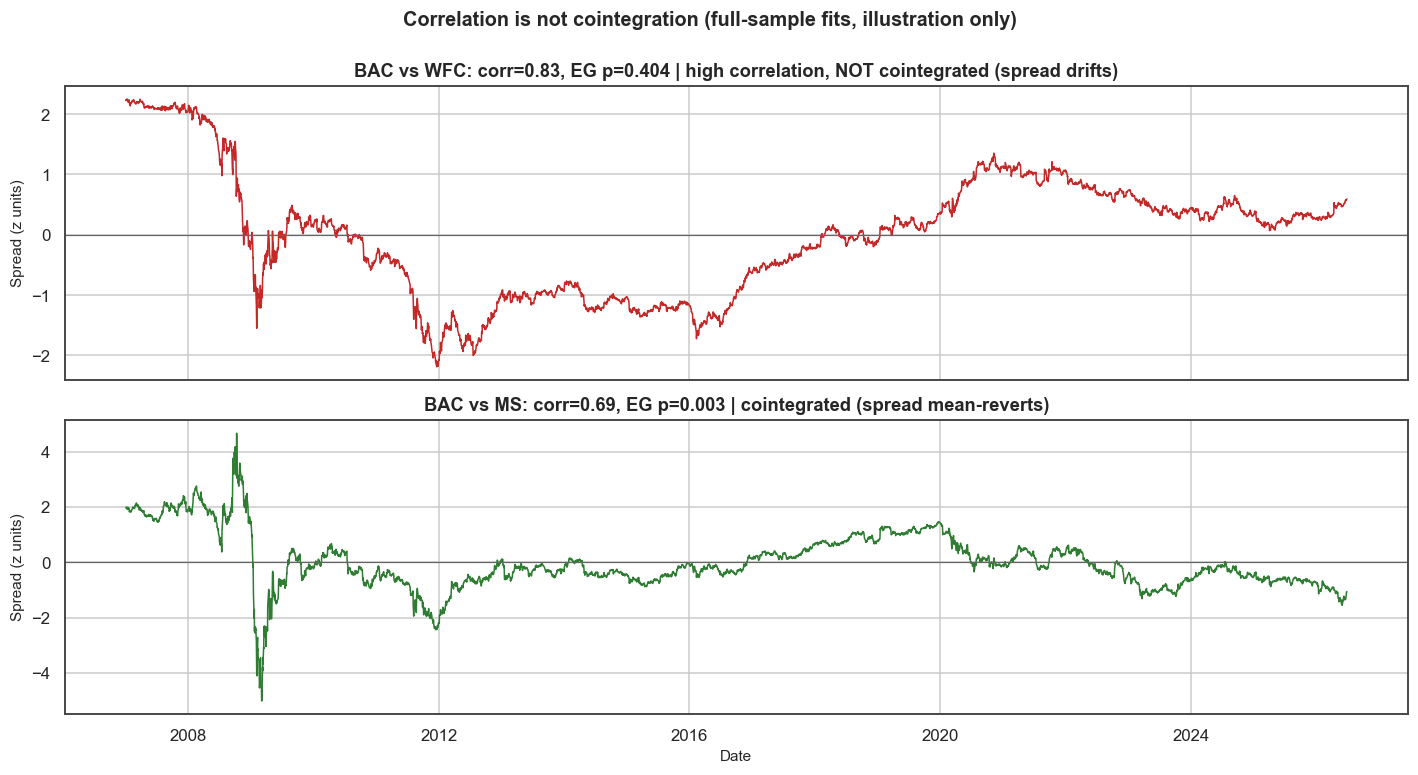

In [11]:
# Correlation is not cointegration: compare the most-correlated pair that FAILS the
# EG test with the pair that passes it most strongly, using full-sample fits
# (illustration only).
corr_flat = sorted(((corr.loc[a, b], a, b) for a, b in itertools.combinations(BANKS, 2)),
                   reverse=True)
drifty = next(((a, b) for c, a, b in corr_flat if pv_full.loc[a, b] > 0.20),
              (corr_flat[0][1], corr_flat[0][2]))
best = min(pairs_flat, key=lambda t: t[2])[:2]


def _full_sample_zspread(a: str, b: str) -> pd.Series:
    """Standardized OLS log-price spread over the full sample (illustration only)."""
    X = sm.add_constant(LOG_PX[b])
    fit = sm.OLS(LOG_PX[a], X).fit()
    s = LOG_PX[a] - float(fit.params.iloc[0]) - float(fit.params.iloc[1]) * LOG_PX[b]
    return (s - s.mean()) / s.std(ddof=1)


fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, (a, b), label, color in [
    (axes[0], drifty, "high correlation, NOT cointegrated (spread drifts)", PALETTE["negative"]),
    (axes[1], best, "cointegrated (spread mean-reverts)", PALETTE["positive"]),
]:
    z = _full_sample_zspread(a, b)
    ax.plot(z.index, z, color=color, lw=1.0)
    ax.axhline(0, color="#666", lw=0.8)
    ax.set_title(f"{a} vs {b}: corr={corr.loc[a, b]:.2f}, EG p={pv_full.loc[a, b]:.3f} | {label}")
    ax.set_ylabel("Spread (z units)")
axes[1].set_xlabel("Date")
fig.suptitle("Correlation is not cointegration (full-sample fits, illustration only)",
             y=1.00, fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

<a id="sec-10"></a>
## 10. Methodology

### 10.1 Cointegration, not correlation

A price series is *integrated of order one*, written $I(1)$, if its level wanders like a random walk but its differences are stationary. Two $I(1)$ log-price series $\ln P^A_t$ and $\ln P^B_t$ are **cointegrated** if some linear combination of them is stationary, $I(0)$:

$$s_t \;=\; \ln P^A_t \;-\; \alpha \;-\; \beta \,\ln P^B_t \;\sim\; I(0)$$

where $\beta$ is the **hedge ratio** (how many log-dollars of B offset one log-dollar of A) and $\alpha$ is a level constant. Stationarity of $s_t$ is what makes the spread *tradable*: it has a well-defined mean to revert to. Correlation says nothing of the sort; two names can be 90% correlated in daily returns while their ratio trends away forever (Section 9 showed a live example). Regressing on **log prices** makes $\beta$ scale-free and the spread a percentage-scale object.

### 10.2 The Engle-Granger two-step test

**Step 1.** Estimate the candidate cointegrating relation by OLS on the formation window:

$$\ln P^A_t = \alpha + \beta \ln P^B_t + \varepsilon_t$$

**Step 2.** Test the residual $\hat\varepsilon_t$ for a unit root with an Augmented Dickey-Fuller (ADF) regression. The null hypothesis is *no cointegration* (the residual is a random walk). Because $\hat\varepsilon_t$ comes from a fitted regression rather than being observed, ordinary ADF critical values are too lenient; `statsmodels.tsa.stattools.coint` applies the MacKinnon (1994, 2010) response-surface critical values that correct for this.

Two honest caveats. First, the test is *asymmetric*: regressing A on B and B on A can give different p-values. This notebook fixes the ordering (first ticker in the pair is the dependent variable) and treats that as part of the strategy definition. Second, Engle-Granger handles exactly two assets. The **Johansen** procedure estimates a vector error-correction model and tests the cointegration *rank*, treating all assets symmetrically and finding multi-asset baskets; it is the right tool for 3+ asset stat-arb and is discussed as an extension in Section 17.

### 10.3 The spread as an Ornstein-Uhlenbeck process, and its half-life

Model the spread as mean-reverting in continuous time:

$$ds_t = \theta\,(\mu - s_t)\,dt + \sigma_{OU}\,dW_t$$

where $\theta$ is the speed of reversion, $\mu$ the long-run mean, $\sigma_{OU}$ the diffusion scale, and $W_t$ a Wiener process. Discretized at daily steps this is an AR(1); subtracting $s_{t-1}$ from both sides gives the regression actually run on the formation window:

$$\Delta s_t = a + b\,s_{t-1} + \eta_t, \qquad b = e^{-\theta \Delta t} - 1 \approx -\theta\,\Delta t$$

so $\hat\theta = -\ln(1 + \hat b)$ per day, and the **half-life** (expected time for a deviation to close half its gap) is

$$t_{1/2} = \frac{\ln 2}{\theta} \approx -\frac{\ln 2}{\hat b}$$

**Why filter on half-life 5 to 60 days?** Below ~5 days the strategy would need to trade almost every reversion cycle: a round trip is four legs at 5 bps each, about 20 bps per unit of capital, which devours the small per-cycle edge, and close-to-close execution cannot even capture intraday reversion. Above ~60 days a 126-day trading window contains fewer than about 1.5 half-lives, so positions tie up capital for months on a reversion estimate that is statistically weak (the half-life regression's precision falls sharply as $b \to 0$). The band keeps only spreads that revert on a horizon the trading window can actually monetize.

### 10.4 Signals: the z-score state machine

Within a trading window, the spread is standardized with **frozen formation-window** parameters:

$$z_t = \frac{s_t - \mu_{form}}{\sigma_{form}}$$

Signals, decided at the close of day $t$ and in force from day $t{+}1$:

- **Enter** short-spread ($u=-1$: short A, long B) when $z_t \ge 2$; enter long-spread ($u=+1$) when $z_t \le -2$. At two formation sigmas the deviation is rare under the formation distribution, so the edge per trade is large enough to clear four legs of costs.
- **Exit** to flat when $|z_t| \le 0.5$. The last half-sigma of reversion has the least expected profit per unit of time, so waiting for exactly zero mostly adds holding time, not P&L.
- **Stop** when $|z_t| \ge 3$, with a **lockout**: after a stop the pair may not re-enter until $|z_t| \le 0.5$ again. A three-sigma excursion is evidence the formation-window relationship broke (a regime change, not a bigger opportunity); the lockout prevents re-shorting a diverging spread on the next bar.
- **Window close-out**: any open position is closed on the final day of the trading window, since next window's parameters (and possibly pairs) differ.

### 10.5 Multiple testing: 66 chances to fool yourself

Each formation window tests $\binom{12}{2} = 66$ pair hypotheses. At $\alpha = 0.05$ pure chance delivers about $66 \times 0.05 \approx 3.3$ "cointegrated" pairs per window even if nothing is cointegrated. Three mitigations are used, and the total test count is reported in Section 12:

1. **Stricter threshold**: $\alpha = 0.01$, cutting the expected false positives per window to $\approx 0.7$. Full Bonferroni ($0.05/66 \approx 0.0008$) is too blunt here because the 66 tests are highly dependent (all banks share a sector factor), which makes Bonferroni severely conservative.
2. **Economic filters**: a false positive must *also* exhibit a plausible OU half-life (5-60 days) and a sane hedge ratio ($0.4 \le \beta \le 2.5$) to be traded; random passers usually fail these.
3. **Implicit persistence**: selection repeats every window, so a lucky pair must keep re-qualifying out of sample to keep drawing capital.

### 10.6 Position sizing and market neutrality

Let $u_t \in \{-1, 0, +1\}$ be the unit spread position. Dollar weights per \$1 of pair capital:

$$w^A_t = \frac{u_t}{1+\beta}, \qquad w^B_t = \frac{-\,u_t\,\beta}{1+\beta}$$

Gross exposure is $|w^A| + |w^B| = |u_t|$, exactly \$1 when active. This weighting *replicates the tested spread*: the position's return is proportional to $\Delta s_t$, the object the cointegration test certified as stationary. Net dollar exposure is $u_t (1-\beta)/(1+\beta)$, which is small for $\beta \approx 1$ and bounded by the $\beta$ hygiene filter. The alternative, forcing strictly dollar-neutral 50/50 legs, trades a *different* linear combination that is only the tested spread when $\beta = 1$; this notebook prefers replicating the certified spread and then **verifying** neutrality empirically: Section 12 regresses strategy returns on SPY and reports the beta with a robust t-statistic.

At the portfolio level, capital is split equally across the $K \le 5$ selected pairs of each window; capital for pairs currently flat sits in cash earning zero (a conservative choice). If no pair qualifies in a window, the book is flat for six months, and that is reported, not hidden.

### 10.7 Frictions and conventions

Costs are charged per leg at 5 bps one-way (commission + half-spread + slippage, realistic for these highly liquid large caps), applied to turnover: $\text{cost}_t = \frac{5}{10^4} \sum_{\text{legs}} |\Delta w_t|$. A full round trip touches four legs, about 20 bps of pair capital. **Gross and net are reported side by side throughout.** Signals live in log-price space; all P&L accounting uses simple returns on dollar weights; annualization multiplies mean daily return by 252 and daily volatility by $\sqrt{252}$.

**Assumptions, stated plainly:** fills at the daily adjusted close (no intraday execution); no borrow fees or short-availability constraints (materially wrong for financials in late 2008, see Section 16); no interest earned on short proceeds or cash; capital reserved per selected pair; stops evaluated at the close only, so a gap through 3 sigma fills at the gapped price.

<a id="sec-11"></a>
## 11. Core Implementation

The engine is built as four separately testable pieces, each followed by a sanity check:

1. **Statistics** (`engle_granger`, `ou_half_life`): the two estimators, verified on simulated series with known properties.
2. **Screening** (`screen_formation_window`, `select_pairs`): apply the estimators to all 66 pairs of one formation window and pass them through the selection funnel.
3. **Signals** (`zscore_positions`): the entry/exit/stop/lockout state machine, verified on a crafted z-path.
4. **Accounting** (`backtest_pair_window`, `run_walk_forward`): dollar legs, turnover, per-leg costs, the trade ledger, and the walk-forward loop that stitches windows together, with structural no-look-ahead assertions inside.

In [12]:
def engle_granger(log_y: pd.Series, log_x: pd.Series) -> Tuple[float, float, float]:
    """Engle-Granger step 1 + cointegration test on two log-price series.

    Returns (p_value, alpha, beta): MacKinnon-surface p-value for the null of NO
    cointegration, and the OLS intercept/hedge-ratio from regressing y on x.
    """
    X = sm.add_constant(log_x)
    fit = sm.OLS(log_y, X).fit()
    alpha, beta = float(fit.params.iloc[0]), float(fit.params.iloc[1])
    p_value = float(coint(log_y, log_x, trend="c")[1])
    return p_value, alpha, beta


def ou_half_life(spread: pd.Series) -> float:
    """OU half-life in days from the AR(1) regression d_s(t) = a + b*s(t-1).

    Returns inf when b >= 0 (no measured reversion), which the selection
    filter then rejects.
    """
    ds = spread.diff().dropna()
    lag = spread.shift(1).loc[ds.index]
    b = float(sm.OLS(ds, sm.add_constant(lag)).fit().params.iloc[1])
    if b >= 0:
        return float("inf")
    theta = -np.log(1.0 + b)
    return float(np.log(2.0) / theta)


# Sanity check on simulated series with KNOWN properties.
_rng = np.random.default_rng(7)
_n = 1500
_x = pd.Series(np.cumsum(_rng.normal(0, 0.01, _n)))
_ar = np.empty(_n)
_ar[0] = 0.0
_theta_true = np.log(2.0) / 15.0                      # designed half-life: 15 days
for _t in range(1, _n):
    _ar[_t] = (1 - _theta_true) * _ar[_t - 1] + _rng.normal(0, 0.008)
_y_coint = pd.Series(0.7 + 1.3 * _x.values + _ar)
_y_indep = pd.Series(np.cumsum(_rng.normal(0, 0.01, _n)))

_p1, _a1, _b1 = engle_granger(_y_coint, _x)
_hl1 = ou_half_life(_y_coint - _a1 - _b1 * _x)
_p2, _, _ = engle_granger(_y_indep, _x)

print(f"Cointegrated sim:  p={_p1:.4f} (expect <0.05)  beta={_b1:.3f} (true 1.30)  "
      f"half-life={_hl1:.1f}d (true 15)")
print(f"Independent sim:   p={_p2:.4f} (expect >0.05)")
assert _p1 < 0.05, "EG failed to detect designed cointegration"
assert _p2 > 0.05, "EG false-positived on independent random walks"
assert 1.1 < _b1 < 1.5, "hedge ratio estimate far from truth"
assert 7 < _hl1 < 30, "half-life estimate far from designed 15d"
print("Sanity checks passed: estimators recover known parameters.")

Cointegrated sim:  p=0.0000 (expect <0.05)  beta=1.306 (true 1.30)  half-life=14.6d (true 15)
Independent sim:   p=0.6002 (expect >0.05)
Sanity checks passed: estimators recover known parameters.


In [13]:
def screen_formation_window(log_px: pd.DataFrame) -> pd.DataFrame:
    """Run EG + OU on every pair of one formation window. One row per pair."""
    rows = []
    for a, b in itertools.combinations(log_px.columns, 2):
        p_value, alpha, beta = engle_granger(log_px[a], log_px[b])
        spread = log_px[a] - alpha - beta * log_px[b]
        rows.append({
            "pair": f"{a}/{b}", "leg_a": a, "leg_b": b, "pvalue": p_value,
            "alpha": alpha, "beta": beta, "half_life": ou_half_life(spread),
            "mu": float(spread.mean()), "sigma": float(spread.std(ddof=1)),
        })
    return pd.DataFrame(rows)


def select_pairs(screen: pd.DataFrame, cfg: Dict) -> pd.DataFrame:
    """Apply the selection funnel and keep the MAX_PAIRS lowest p-values."""
    ok = screen[
        (screen["pvalue"] <= cfg["EG_PVALUE_MAX"])
        & screen["half_life"].between(cfg["HALF_LIFE_MIN"], cfg["HALF_LIFE_MAX"])
        & screen["beta"].between(cfg["BETA_MIN"], cfg["BETA_MAX"])
        & (screen["sigma"] > 0)
    ]
    return ok.nsmallest(cfg["MAX_PAIRS"], "pvalue").reset_index(drop=True)


# Sanity check: the funnel on the FIRST formation window, stage by stage.
_first_form = LOG_PX.iloc[:CONFIG["FORMATION_DAYS"]]
_scr = screen_formation_window(_first_form)
_n0 = len(_scr)
_n1 = int((_scr["pvalue"] <= CONFIG["EG_PVALUE_MAX"]).sum())
_pass_hl = ((_scr["pvalue"] <= CONFIG["EG_PVALUE_MAX"])
            & _scr["half_life"].between(CONFIG["HALF_LIFE_MIN"], CONFIG["HALF_LIFE_MAX"]))
_n2 = int(_pass_hl.sum())
_n3 = int((_pass_hl
           & _scr["beta"].between(CONFIG["BETA_MIN"], CONFIG["BETA_MAX"])).sum())
_sel = select_pairs(_scr, CONFIG)
print(f"First formation window ({_first_form.index.min().date()} -> "
      f"{_first_form.index.max().date()}):")
print(f"  {_n0} pairs tested -> {_n1} pass EG p<={CONFIG['EG_PVALUE_MAX']} "
      f"-> {_n2} also pass half-life filter -> {_n3} also pass beta bounds "
      f"-> {len(_sel)} selected (max {CONFIG['MAX_PAIRS']})")
assert _scr["pvalue"].between(0, 1).all(), "p-values outside [0,1]"
if len(_sel):
    display(_sel[["pair", "pvalue", "beta", "half_life"]].round(4))

First formation window (2007-01-03 -> 2008-12-31):
  66 pairs tested -> 5 pass EG p<=0.01 -> 5 also pass half-life filter -> 0 also pass beta bounds -> 0 selected (max 5)


In [14]:
def zscore_positions(z: pd.Series, entry: float, exit_band: float,
                     stop: float) -> pd.Series:
    """Unit spread position u(t), decided at the close of day t.

    +1 = long spread (long A, short B), -1 = short spread, 0 = flat.
    Enter when entry <= |z| < stop; exit when |z| <= exit_band; stop out when
    |z| >= stop, then stay locked out until |z| <= exit_band; forced flat on the
    final day (window close-out). The caller shifts u by one day before applying
    returns, so a signal at close t first earns money on day t+1.
    """
    u = np.zeros(len(z))
    state, locked = 0, False
    for t, z_t in enumerate(z.values):
        if state == 0:
            if locked:
                if abs(z_t) <= exit_band:
                    locked = False
            elif entry <= abs(z_t) < stop:
                state = -1 if z_t > 0 else 1
        else:
            if abs(z_t) >= stop:
                state, locked = 0, True
            elif abs(z_t) <= exit_band:
                state = 0
        u[t] = state
    if len(u):
        u[-1] = 0
    return pd.Series(u, index=z.index)


# Sanity check on a crafted z path covering entry, exit, stop, and lockout.
_zpath = pd.Series([0.0, 1.0, 2.2, 1.5, 0.4, -2.5, -3.2, -1.0, -0.3, 2.6, 0.0])
_expected = [0, 0, -1, -1, 0, 1, 0, 0, 0, -1, 0]
_u = zscore_positions(_zpath, CONFIG["ENTRY_Z"], CONFIG["EXIT_Z"], CONFIG["STOP_Z"])
assert _u.tolist() == _expected, f"state machine mismatch: {_u.tolist()}"
print("State machine sanity check passed:")
print(pd.DataFrame({"z": _zpath, "u": _u.astype(int)}).T)
print("Reading: enter short at z=2.2, exit at 0.4; enter long at -2.5, STOP at -3.2,")
print("locked out at -1.0, unlocked at -0.3; re-enter short at 2.6; forced flat at end.")

State machine sanity check passed:
    0    1    2    3    4    5    6    7    8    9    10
z  0.0  1.0  2.2  1.5  0.4 -2.5 -3.2 -1.0 -0.3  2.6  0.0
u  0.0  0.0 -1.0 -1.0  0.0  1.0  0.0  0.0  0.0 -1.0  0.0
Reading: enter short at z=2.2, exit at 0.4; enter long at -2.5, STOP at -3.2,
locked out at -1.0, unlocked at -0.3; re-enter short at 2.6; forced flat at end.


In [15]:
@dataclass
class PairWindowResult:
    """Daily accounting and trade ledger for one pair in one trading window."""
    pair: str
    daily: pd.DataFrame          # columns: gross, net, turnover, u, z
    trades: pd.DataFrame


def backtest_pair_window(px_a: pd.Series, px_b: pd.Series, r_a: pd.Series,
                         r_b: pd.Series, params: Dict, cfg: Dict,
                         window_id: int) -> PairWindowResult:
    """Backtest one selected pair over one trading window with frozen parameters.

    params holds alpha/beta/mu/sigma estimated on the FORMATION window only.
    Costs are charged on turnover the day a trade happens; positions earn the
    NEXT day's return (u is shifted before touching returns).
    """
    beta, alpha = params["beta"], params["alpha"]
    mu, sigma = params["mu"], params["sigma"]

    spread = np.log(px_a) - alpha - beta * np.log(px_b)
    z = (spread - mu) / sigma
    u = zscore_positions(z, cfg["ENTRY_Z"], cfg["EXIT_Z"], cfg["STOP_Z"])

    w_a = u / (1.0 + beta)
    w_b = -u * beta / (1.0 + beta)
    held_a = w_a.shift(1).fillna(0.0)
    held_b = w_b.shift(1).fillna(0.0)

    gross = held_a * r_a + held_b * r_b
    turnover = (w_a - held_a).abs() + (w_b - held_b).abs()
    net = gross - turnover * (cfg["COST_PER_LEG_BPS"] / 1e4)

    daily = pd.DataFrame({"gross": gross, "net": net, "turnover": turnover,
                          "u": u, "z": z})

    trades = []
    prev_u, entry_t = 0, None
    for t in range(len(u)):
        u_t = int(u.iloc[t])
        if prev_u == 0 and u_t != 0:
            entry_t = t
        elif prev_u != 0 and u_t == 0 and entry_t is not None:
            if t == len(u) - 1 and abs(z.iloc[t]) > cfg["EXIT_Z"] \
                    and abs(z.iloc[t]) < cfg["STOP_Z"]:
                reason = "window_end"
            elif abs(z.iloc[t]) >= cfg["STOP_Z"]:
                reason = "stop"
            else:
                reason = "reverted"
            trades.append({
                "window": window_id, "pair": params["pair"],
                "side": "long_spread" if prev_u > 0 else "short_spread",
                "entry_date": u.index[entry_t], "exit_date": u.index[t],
                "entry_z": float(z.iloc[entry_t]), "exit_z": float(z.iloc[t]),
                "holding_days": t - entry_t,
                "net_pnl_pair": float(net.iloc[entry_t:t + 1].sum()),
                "exit_reason": reason,
            })
            entry_t = None
        prev_u = u_t
    return PairWindowResult(params["pair"], daily, pd.DataFrame(trades))


# Sanity check: run the first selected pair on the first trading window and
# verify the accounting identities hold.
_trade_idx = PRICES.index[CONFIG["FORMATION_DAYS"]:CONFIG["FORMATION_DAYS"] + CONFIG["TRADE_DAYS"]]
if len(_sel):
    _p = _sel.iloc[0].to_dict()
    _res = backtest_pair_window(
        PRICES[_p["leg_a"]].loc[_trade_idx], PRICES[_p["leg_b"]].loc[_trade_idx],
        RETS[_p["leg_a"]].loc[_trade_idx], RETS[_p["leg_b"]].loc[_trade_idx],
        _p, CONFIG, window_id=0)
    _d = _res.daily
    _cost_rate = CONFIG["COST_PER_LEG_BPS"] / 1e4
    assert np.allclose(_d["net"], _d["gross"] - _d["turnover"] * _cost_rate), \
        "net != gross - costs"
    _active = _d["u"].shift(1).fillna(0) != 0
    _gross_exp = (_d["u"].shift(1).fillna(0).abs())
    assert (_gross_exp[_active] == 1.0).all(), "gross exposure != $1 when active"
    _net_exp = abs(1 - _p["beta"]) / (1 + _p["beta"])
    print(f"Pair {_p['pair']}: {len(_res.trades)} trade(s) in the first window; "
          f"identities hold (net = gross - turnover x {_cost_rate:.4%}).")
    print(f"Gross exposure when active: $1.00 per $1 pair capital; "
          f"structural net exposure |1-beta|/(1+beta) = {_net_exp:.1%}.")
else:
    print("No pair selected in the first window; accounting check runs inside the engine.")

No pair selected in the first window; accounting check runs inside the engine.


In [16]:
@dataclass
class WalkForwardResult:
    """Everything the walk-forward run produces, in one object."""
    gross: pd.Series             # daily portfolio gross return (per $1 capital)
    net: pd.Series               # daily portfolio net return
    turnover: pd.Series          # daily portfolio turnover (per $1 capital)
    trades: pd.DataFrame         # one row per round trip
    selections: pd.DataFrame     # one row per (window, selected pair)
    pair_net: pd.DataFrame       # per-pair daily net contribution, portfolio scale
    windows: List[Dict]          # window metadata for the look-ahead audit
    n_tests: int                 # total EG hypotheses examined


def run_walk_forward(prices: pd.DataFrame, cfg: Dict,
                     screen_cache: Optional[Dict] = None,
                     quiet: bool = False) -> WalkForwardResult:
    """Rolling formation/trading walk-forward over the whole sample.

    For each window: screen pairs on [s, s+F), select, then trade [s+F, s+F+T)
    with frozen parameters. screen_cache (keyed by (start_index, F)) lets
    robustness reruns skip repeated cointegration tests. Trailing windows
    shorter than 21 days are skipped.
    """
    if screen_cache is None:
        screen_cache = {}
    log_px = np.log(prices)
    rets = prices.pct_change().fillna(0.0)
    idx = prices.index
    F, T = cfg["FORMATION_DAYS"], cfg["TRADE_DAYS"]

    gross_parts, net_parts, turn_parts = [], [], []
    trades_all, selections_all, windows_meta = [], [], []
    pair_net_acc: Dict[str, List[pd.Series]] = {}
    n_tests = 0

    starts = [s for s in range(0, len(idx) - F, T) if len(idx) - (s + F) >= 21]
    iterator = starts if quiet else tqdm(starts, desc="walk-forward windows")
    for w_id, s in enumerate(iterator):
        form_idx = idx[s:s + F]
        trade_idx = idx[s + F:min(s + F + T, len(idx))]
        assert form_idx[-1] < trade_idx[0], "formation overlaps trading window"
        windows_meta.append({"window": w_id, "form_start": form_idx[0],
                             "form_end": form_idx[-1], "trade_start": trade_idx[0],
                             "trade_end": trade_idx[-1]})

        key = (s, F)
        if key not in screen_cache:
            screen_cache[key] = screen_formation_window(log_px.loc[form_idx])
        n_tests += len(screen_cache[key])
        selected = select_pairs(screen_cache[key], cfg)

        w_gross = pd.Series(0.0, index=trade_idx)
        w_net = pd.Series(0.0, index=trade_idx)
        w_turn = pd.Series(0.0, index=trade_idx)
        k = len(selected)
        for _, row in selected.iterrows():
            params = row.to_dict()
            res = backtest_pair_window(
                prices[params["leg_a"]].loc[trade_idx],
                prices[params["leg_b"]].loc[trade_idx],
                rets[params["leg_a"]].loc[trade_idx],
                rets[params["leg_b"]].loc[trade_idx],
                params, cfg, window_id=w_id)
            w_gross += res.daily["gross"] / k
            w_net += res.daily["net"] / k
            w_turn += res.daily["turnover"] / k
            if not res.trades.empty:
                t = res.trades.copy()
                t["net_pnl_portfolio"] = t["net_pnl_pair"] / k
                trades_all.append(t)
            pair_net_acc.setdefault(params["pair"], []).append(res.daily["net"] / k)
            selections_all.append({"window": w_id, "trade_start": trade_idx[0],
                                   "trade_end": trade_idx[-1],
                                   **{f: params[f] for f in
                                      ("pair", "leg_a", "leg_b", "pvalue", "beta",
                                       "alpha", "mu", "sigma", "half_life")}})
        gross_parts.append(w_gross)
        net_parts.append(w_net)
        turn_parts.append(w_turn)

    gross = pd.concat(gross_parts)
    net = pd.concat(net_parts)
    turn = pd.concat(turn_parts)
    assert not gross.index.duplicated().any(), "trading windows overlap"
    assert gross.index.is_monotonic_increasing, "trading days out of order"

    pair_net = pd.DataFrame({p: pd.concat(chunks).reindex(gross.index).fillna(0.0)
                             for p, chunks in pair_net_acc.items()})
    trades = (pd.concat(trades_all, ignore_index=True)
              if trades_all else pd.DataFrame())
    selections = pd.DataFrame(selections_all)
    return WalkForwardResult(gross, net, turn, trades, selections,
                             pair_net, windows_meta, n_tests)


SCREENS: Dict = {}
result = run_walk_forward(PRICES, CONFIG, SCREENS)

n_windows = len(result.windows)
n_active = result.selections["window"].nunique() if not result.selections.empty else 0
ann = np.sqrt(TRADING_DAYS_PER_YEAR)
sh_g = result.gross.mean() / result.gross.std(ddof=1) * ann
sh_n = result.net.mean() / result.net.std(ddof=1) * ann
print(f"\nWalk-forward complete: {n_windows} windows "
      f"({result.gross.index.min().date()} -> {result.gross.index.max().date()}), "
      f"{n_active} with at least one qualifying pair.")
print(f"EG hypotheses examined: {result.n_tests:,} | round trips: {len(result.trades)} | "
      f"unique pairs ever selected: {result.selections['pair'].nunique() if not result.selections.empty else 0}")
print(f"Quick look (details in Section 13): gross Sharpe {sh_g:.2f}, net Sharpe {sh_n:.2f}")

# Benchmarks aligned to the out-of-sample dates.
OOS_IDX = result.net.index
BENCH_OOS = BENCH_RET.loc[OOS_IDX]
EW_OOS = RETS[BANKS].mean(axis=1).loc[OOS_IDX]
print(f"Benchmarks aligned: SPY and equal-weight basket over {len(OOS_IDX):,} OOS days.")

walk-forward windows:   0%|          | 0/35 [00:00<?, ?it/s]

walk-forward windows:   3%|▎         | 1/35 [00:00<00:21,  1.55it/s]

walk-forward windows:   6%|▌         | 2/35 [00:01<00:19,  1.68it/s]

walk-forward windows:   9%|▊         | 3/35 [00:01<00:18,  1.75it/s]

walk-forward windows:  11%|█▏        | 4/35 [00:02<00:17,  1.75it/s]

...

walk-forward windows:  94%|█████████▍| 33/35 [00:17<00:01,  1.87it/s]

walk-forward windows:  97%|█████████▋| 34/35 [00:18<00:00,  1.87it/s]

walk-forward windows: 100%|██████████| 35/35 [00:18<00:00,  1.88it/s]

walk-forward windows: 100%|██████████| 35/35 [00:18<00:00,  1.84it/s]


Walk-forward complete: 35 windows (2009-01-02 -> 2026-06-29), 23 with at least one qualifying pair.
EG hypotheses examined: 2,310 | round trips: 57 | unique pairs ever selected: 25
Quick look (details in Section 13): gross Sharpe 0.68, net Sharpe 0.64
Benchmarks aligned: SPY and equal-weight basket over 4,398 OOS days.


<a id="sec-12"></a>
## 12. Validation and Statistical Rigor

The classic way a pairs backtest lies is **circular selection**: pick pairs on the full history, then "backtest" on that same history. Every parameter that matters here (which pairs, $\beta$, $\mu$, $\sigma$) was estimated on formation windows and applied strictly afterward, and this section audits that claim rather than asserting it:

1. **Structural audit**: every formation window ends before its trading window begins, and has exactly the configured length.
2. **Parameter provenance audit**: re-derive the stored parameters of a traded pair from its formation window alone and confirm they match to machine precision.
3. **Execution-lag guardrail**: positions held on day $t$ must have been decided at $t{-}1$; a sign-match test flags a signal that suspiciously "knows" the same bar.
4. **The cautionary in-sample comparison**: the same trading rules, but with selection and parameters fitted on the full sample. This is the number a careless circular backtest would report, shown once and labeled as such.
5. **Significance**: a Newey-West t-statistic on daily net returns (robust to autocorrelation), a Lo (2002) confidence interval on the Sharpe ratio, and the market-neutrality regression of strategy returns on SPY with HAC standard errors.

The multiple-testing exposure is also totaled here: the number of cointegration hypotheses examined across all windows, and how many false positives that volume of testing would produce by chance at the chosen threshold.

In [17]:
def newey_west_tstat(series: pd.Series, lags: int = 21) -> Tuple[float, float]:
    """HAC t-stat and p-value that the mean of a daily return series is nonzero.

    Newey-West standard errors are robust to the autocorrelation and volatility
    clustering that make plain t-tests overstate significance on financial returns.
    """
    y = np.asarray(series.dropna(), dtype=float)
    fit = sm.OLS(y, np.ones((len(y), 1))).fit(cov_type="HAC",
                                              cov_kwds={"maxlags": lags})
    return float(fit.tvalues[0]), float(fit.pvalues[0])


def sharpe_ci(returns: pd.Series, conf: float = 0.95) -> Tuple[float, float, float]:
    """Annualized Sharpe with the Lo (2002) analytic confidence interval."""
    from scipy import stats as st
    r = returns.dropna()
    sr_d = float(r.mean() / r.std(ddof=1))
    se = np.sqrt((1 + 0.5 * sr_d ** 2) / len(r))
    z = st.norm.ppf(0.5 + conf / 2)
    a = np.sqrt(TRADING_DAYS_PER_YEAR)
    return sr_d * a, (sr_d - z * se) * a, (sr_d + z * se) * a


# Audit 1: structural. Formation strictly precedes trading, correct length.
for w in result.windows:
    assert w["form_end"] < w["trade_start"], f"window {w['window']}: leak"
form_lengths = {len(PRICES.loc[w["form_start"]:w["form_end"]]) for w in result.windows}
assert form_lengths == {CONFIG["FORMATION_DAYS"]}, f"formation lengths off: {form_lengths}"
print(f"Audit 1 PASS: {len(result.windows)} windows; every formation window "
      f"({CONFIG['FORMATION_DAYS']} days) ends before its trading window starts.")

# Audit 2: parameter provenance. Recompute a traded pair's parameters from its
# formation window alone and match the stored values exactly.
if not result.selections.empty:
    _mid = result.selections.iloc[len(result.selections) // 2]
    _w = result.windows[int(_mid["window"])]
    _form = LOG_PX.loc[_w["form_start"]:_w["form_end"]]
    _pv, _al, _be = engle_granger(_form[_mid["leg_a"]], _form[_mid["leg_b"]])
    _sp = _form[_mid["leg_a"]] - _al - _be * _form[_mid["leg_b"]]
    assert np.isclose(_be, _mid["beta"]) and np.isclose(_pv, _mid["pvalue"])
    assert np.isclose(float(_sp.mean()), _mid["mu"]) and \
        np.isclose(float(_sp.std(ddof=1)), _mid["sigma"])
    print(f"Audit 2 PASS: {_mid['pair']} (window {int(_mid['window'])}) parameters "
          f"re-derived from formation data only; stored values match exactly.")

# Audit 3: execution-lag guardrail on the most-traded pair.
if not result.selections.empty:
    SHOWCASE = result.selections["pair"].value_counts().idxmax()
    _a, _b = SHOWCASE.split("/")
    _rows = result.selections[result.selections["pair"] == SHOWCASE]
    _hits, _n = 0, 0
    for _, r_ in _rows.iterrows():
        _tidx = OOS_IDX[(OOS_IDX >= r_["trade_start"]) & (OOS_IDX <= r_["trade_end"])]
        _s = LOG_PX[_a].loc[_tidx] - r_["alpha"] - r_["beta"] * LOG_PX[_b].loc[_tidx]
        _z = (_s - r_["mu"]) / r_["sigma"]
        _u = zscore_positions(_z, CONFIG["ENTRY_Z"], CONFIG["EXIT_Z"], CONFIG["STOP_Z"])
        _held = _u.shift(1).fillna(0.0)
        _ds = _s.diff().fillna(0.0)
        _mask = _held != 0
        _hits += int((np.sign(_held[_mask]) == np.sign(_ds[_mask])).sum())
        _n += int(_mask.sum())
    _hit_rate = _hits / max(_n, 1)
    assert _hit_rate < 0.95, "positions match same-day spread moves suspiciously often"
    print(f"Audit 3 PASS: held positions match same-day spread moves {_hit_rate:.0%} "
          f"of the time (a leaked same-bar signal would approach 100%). "
          f"A guardrail, not a proof; audits 1-2 are the structural guarantee.")

# Multiple-testing exposure.
exp_fp = result.n_tests * CONFIG["EG_PVALUE_MAX"]
n_selected = len(result.selections)
print(f"\nMultiple testing: {result.n_tests:,} EG hypotheses examined across "
      f"{len(result.windows)} windows. At p<={CONFIG['EG_PVALUE_MAX']}, chance alone "
      f"would pass ~{exp_fp:.0f}; the funnel actually selected {n_selected} "
      f"(pair-windows), further filtered by half-life and hedge-ratio bounds.")

Audit 1 PASS: 35 windows; every formation window (504 days) ends before its trading window starts.
Audit 2 PASS: SCHW/COF (window 12) parameters re-derived from formation data only; stored values match exactly.
Audit 3 PASS: held positions match same-day spread moves 58% of the time (a leaked same-bar signal would approach 100%). A guardrail, not a proof; audits 1-2 are the structural guarantee.

Multiple testing: 2,310 EG hypotheses examined across 35 windows. At p<=0.01, chance alone would pass ~23; the funnel actually selected 44 (pair-windows), further filtered by half-life and hedge-ratio bounds.


### 12.1 The cautionary comparison: what in-sample selection would have claimed

Same trading rules, same costs, same execution lag. The only change: pairs are picked, and $\beta, \mu, \sigma$ estimated, on the **full 2007-2026 sample**, then "backtested" on that same sample. One telling detail: the strategy's own strict funnel (p $\le$ 0.01 plus half-life and beta bounds) selects *nothing* over the full 19 years, because tight cointegration is episodic and does not persist for two decades. The classic circular backtest does not stop there; it simply ranks all 66 pairs by full-sample p-value and takes the best five. That naive version is reproduced below, labeled, so it can be compared with the honest walk-forward number; it is used nowhere else in the notebook. Whether the circular version happens to flatter the headline number in a given sample or not, it is untrustworthy by construction: nobody standing in 2009 could have named those five pairs.

Strict funnel applied to the FULL sample selects 0 pair(s). The naive backtest ranks by p-value and trades the top 5 anyway:


,pair,pvalue,beta,half_life
0,BAC/MS,0.0029,0.7803,173.2588
1,USB/TFC,0.0066,1.0083,65.0666
2,C/STT,0.0093,0.6814,288.1630
3,PNC/TFC,0.0205,1.4444,74.3895
4,C/GS,0.0218,0.4072,298.3867


,net Sharpe,net CAGR,max drawdown,pairs
"IN-SAMPLE selection (circular, do not report)",0.641,0.031,-0.160,5 fixed for 19y
Walk-forward out-of-sample (honest),0.643,0.030,-0.104,re-selected every 6m


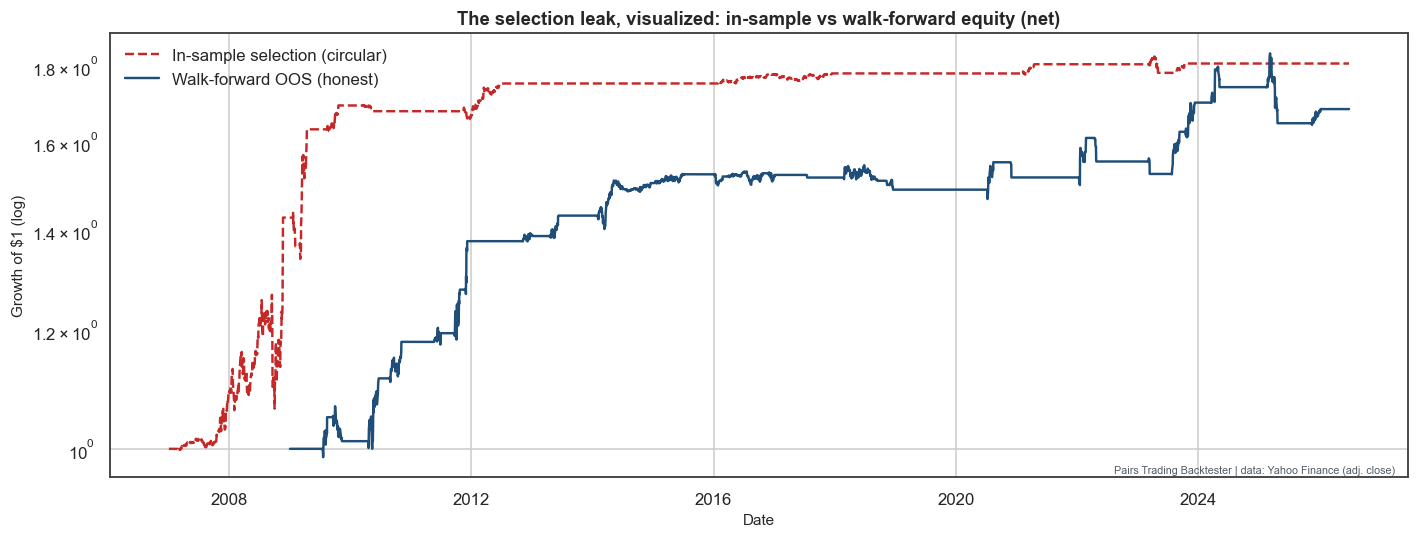

Identical rules, costs, and execution lag. In-sample Sharpe 0.64 vs walk-forward 0.64 (gap -0.00); in-sample max drawdown -16.0% vs -10.4%.
Whether the leak flatters the headline number in a particular sample or not, its size is unknowable in advance, and the honest funnel rejects every one of these full-sample pairs. That is why selection must be out of sample.


In [18]:
_ann = np.sqrt(TRADING_DAYS_PER_YEAR)


def _quick_sharpe(r: pd.Series) -> float:
    sd = r.std(ddof=1)
    return float(r.mean() / sd * _ann) if sd > 0 else np.nan


def _quick_cagr(r: pd.Series) -> float:
    yrs = len(r) / TRADING_DAYS_PER_YEAR
    return float((1 + r).prod() ** (1 / yrs) - 1) if yrs > 0 else np.nan


def _quick_maxdd(r: pd.Series) -> float:
    w = (1 + r).cumprod()
    return float((w / w.cummax() - 1).min())


# Full-sample (in-sample) selection and parameters. Deliberately leaky: rank all
# pairs by full-sample p-value and take the top MAX_PAIRS, the way a careless
# backtest does. (The strict funnel selects nothing over 19 years, which is
# itself evidence that long-sample cointegration is an illusion here.)
screen_full = screen_formation_window(LOG_PX)
n_strict = len(select_pairs(screen_full, CONFIG))
print(f"Strict funnel applied to the FULL sample selects {n_strict} pair(s). "
      f"The naive backtest ranks by p-value and trades the top "
      f"{CONFIG['MAX_PAIRS']} anyway:")
sel_is = screen_full.nsmallest(CONFIG["MAX_PAIRS"], "pvalue").reset_index(drop=True)
display(sel_is[["pair", "pvalue", "beta", "half_life"]].round(4))
if len(sel_is):
    is_net = pd.Series(0.0, index=PRICES.index)
    for _, row in sel_is.iterrows():
        p = row.to_dict()
        res_is = backtest_pair_window(PRICES[p["leg_a"]], PRICES[p["leg_b"]],
                                      RETS[p["leg_a"]], RETS[p["leg_b"]],
                                      p, CONFIG, window_id=-1)
        is_net += res_is.daily["net"] / len(sel_is)

    compare = pd.DataFrame({
        "net Sharpe": [_quick_sharpe(is_net), _quick_sharpe(result.net)],
        "net CAGR": [_quick_cagr(is_net), _quick_cagr(result.net)],
        "max drawdown": [_quick_maxdd(is_net), _quick_maxdd(result.net)],
        "pairs": [f"{len(sel_is)} fixed for 19y", "re-selected every 6m"],
    }, index=["IN-SAMPLE selection (circular, do not report)",
              "Walk-forward out-of-sample (honest)"])
    display(compare.round(3))

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot((1 + is_net).cumprod(), color=PALETTE["negative"], ls="--",
            label="In-sample selection (circular)")
    ax.plot((1 + result.net).cumprod().reindex(PRICES.index),
            color=PALETTE["strategy"], label="Walk-forward OOS (honest)")
    ax.set_yscale("log")
    ax.set_title("The selection leak, visualized: in-sample vs walk-forward equity (net)")
    ax.set_ylabel("Growth of $1 (log)")
    ax.set_xlabel("Date")
    ax.legend(loc="upper left")
    ax.annotate(SOURCE_NOTE, xy=(0.99, 0.01), xycoords="axes fraction",
                ha="right", fontsize=7, color=PALETTE["neutral"])
    plt.tight_layout()
    plt.show()
    gap = _quick_sharpe(is_net) - _quick_sharpe(result.net)
    print(f"Identical rules, costs, and execution lag. In-sample Sharpe "
          f"{_quick_sharpe(is_net):.2f} vs walk-forward {_quick_sharpe(result.net):.2f} "
          f"(gap {gap:+.2f}); in-sample max drawdown {_quick_maxdd(is_net):.1%} vs "
          f"{_quick_maxdd(result.net):.1%}.")
    print("Whether the leak flatters the headline number in a particular sample or "
          "not, its size is unknowable in advance, and the honest funnel rejects "
          "every one of these full-sample pairs. That is why selection must be out "
          "of sample.")
else:
    print("Screen produced no rows; the in-sample comparison is skipped.")

### 12.2 Significance and market neutrality

Three numbers a desk would demand before believing any of this. The Newey-West t-statistic asks whether the mean daily net return is distinguishable from zero once autocorrelation is accounted for; $|t| \ge 2$ is the conventional bar. The Lo interval puts error bars on the Sharpe ratio itself. The SPY regression tests the strategy's core promise, market neutrality: $\beta$ should be statistically indistinguishable from zero, and whatever return exists should live in the intercept $\alpha$.

In [19]:
t_nw, p_nw = newey_west_tstat(result.net)
sr, sr_lo, sr_hi = sharpe_ci(result.net)

X_mkt = sm.add_constant(BENCH_OOS.values)
mkt_fit = sm.OLS(result.net.values, X_mkt).fit(cov_type="HAC",
                                               cov_kwds={"maxlags": 21})
alpha_ann = float(mkt_fit.params[0]) * TRADING_DAYS_PER_YEAR
beta_mkt = float(mkt_fit.params[1])
t_alpha, t_beta = float(mkt_fit.tvalues[0]), float(mkt_fit.tvalues[1])

print("Significance of daily NET returns (walk-forward OOS):")
print(f"  Newey-West t-stat : {t_nw:+.2f}  (p = {p_nw:.3f})")
print(f"  Sharpe (Lo 95% CI): {sr:.2f}  [{sr_lo:.2f}, {sr_hi:.2f}]")
print("\nMarket neutrality (net returns ~ alpha + beta * SPY, HAC errors):")
print(f"  beta to SPY       : {beta_mkt:+.3f}  (t = {t_beta:+.2f})")
print(f"  annualized alpha  : {alpha_ann:+.2%}  (t = {t_alpha:+.2f})")
neutral = "PASS: beta statistically indistinguishable from zero (|t| < 2)" \
    if abs(t_beta) < 2 else "FAIL: beta significantly nonzero; NOT market-neutral"
print(f"  {neutral}")

SIGNIF = {"t_nw": t_nw, "p_nw": p_nw, "sharpe": sr, "sr_lo": sr_lo, "sr_hi": sr_hi,
          "beta": beta_mkt, "t_beta": t_beta, "alpha_ann": alpha_ann,
          "t_alpha": t_alpha}

Significance of daily NET returns (walk-forward OOS):
  Newey-West t-stat : +2.81  (p = 0.005)
  Sharpe (Lo 95% CI): 0.64  [0.17, 1.11]

Market neutrality (net returns ~ alpha + beta * SPY, HAC errors):
  beta to SPY       : -0.010  (t = -0.75)
  annualized alpha  : +3.26%  (t = +2.99)
  PASS: beta statistically indistinguishable from zero (|t| < 2)


<a id="sec-13"></a>
## 13. Results and Performance Metrics

All numbers below are **walk-forward out-of-sample, net of 5 bps per leg** unless a row is labeled gross. Benchmarks: SPY buy-and-hold (the market the strategy claims independence from) and a naive equal-weight long-only basket of the 12 banks (what "just buy the sector" earned over the same days). The risk-free rate is set to zero for all Sharpe ratios, applied uniformly so the comparison is internally consistent.

In [20]:
from scipy import stats as scistats


def drawdown_series(returns: pd.Series) -> pd.Series:
    """Drawdown from running peak of the compounded wealth curve."""
    w = (1 + returns).cumprod()
    return w / w.cummax() - 1.0


def performance_summary(returns: pd.Series, name: str) -> Dict:
    """Headline performance and risk metrics for one daily return series."""
    r = returns.dropna()
    yrs = len(r) / TRADING_DAYS_PER_YEAR
    wealth = float((1 + r).prod())
    sd = r.std(ddof=1)
    downside = np.minimum(r, 0.0)
    dd_ann = float(np.sqrt((downside ** 2).mean()) * np.sqrt(TRADING_DAYS_PER_YEAR))
    mdd = float(drawdown_series(r).min())
    cagr = wealth ** (1 / yrs) - 1 if yrs > 0 else np.nan
    q05 = float(r.quantile(0.05))
    tail = r[r <= q05]
    return {
        "Series": name,
        "CAGR": cagr,
        "Ann.Vol": float(sd * np.sqrt(TRADING_DAYS_PER_YEAR)),
        "Sharpe": float(r.mean() / sd * np.sqrt(TRADING_DAYS_PER_YEAR)) if sd > 0 else np.nan,
        "Sortino": float(r.mean() * TRADING_DAYS_PER_YEAR / dd_ann) if dd_ann > 0 else np.nan,
        "Calmar": float(cagr / abs(mdd)) if mdd < 0 else np.nan,
        "MaxDD": mdd,
        "HitRate": float((r > 0).mean()),
        "VaR95": -q05,
        "CVaR95": float(-tail.mean()) if len(tail) else np.nan,
        "Skew": float(scistats.skew(r)),
        "Kurtosis": float(scistats.kurtosis(r)),
    }


summary_df = pd.DataFrame([
    performance_summary(result.net, "Pairs strategy (NET)"),
    performance_summary(result.gross, "Pairs strategy (gross)"),
    performance_summary(BENCH_OOS, "SPY buy-and-hold"),
    performance_summary(EW_OOS, "Equal-weight bank basket"),
]).set_index("Series")
display(summary_df.round(3))
summary_df.to_csv(os.path.join(OUTPUT_DIR, "pairs_summary_metrics.csv"))

cost_drag = _quick_cagr(result.gross) - _quick_cagr(result.net)
print(f"\nCost drag: {cost_drag:.2%} of CAGR per year is paid to frictions "
      f"({CONFIG['COST_PER_LEG_BPS']:.0f} bps per leg). Gross vs net is the "
      f"difference between a paper strategy and a tradable one.")

,CAGR,Ann.Vol,Sharpe,Sortino,Calmar,MaxDD,HitRate,VaR95,CVaR95,Skew,Kurtosis
Series,,,,,,,,,,,
Pairs strategy (NET),0.030,0.048,0.643,1.074,0.292,-0.104,0.148,0.002,0.006,2.920,57.979
Pairs strategy (gross),0.032,0.048,0.679,1.139,0.311,-0.103,0.148,0.002,0.006,2.950,57.964
SPY buy-and-hold,0.149,0.178,0.868,1.231,0.441,-0.337,0.554,0.017,0.027,-0.257,10.521
Equal-weight bank basket,0.141,0.323,0.568,0.842,0.252,-0.557,0.521,0.027,0.045,0.581,19.807



Cost drag: 0.18% of CAGR per year is paid to frictions (5 bps per leg). Gross vs net is the difference between a paper strategy and a tradable one.


In [21]:
# Trade statistics and per-pair attribution.
if not result.trades.empty:
    tr = result.trades
    exit_counts = tr["exit_reason"].value_counts()
    trade_stats = pd.Series({
        "round trips": len(tr),
        "win rate (net)": (tr["net_pnl_pair"] > 0).mean(),
        "avg net P&L per trade (bps of pair capital)": tr["net_pnl_pair"].mean() * 1e4,
        "median holding (days)": tr["holding_days"].median(),
        "mean holding (days)": tr["holding_days"].mean(),
        "exits: reverted": int(exit_counts.get("reverted", 0)),
        "exits: stopped (3 sigma)": int(exit_counts.get("stop", 0)),
        "exits: window end": int(exit_counts.get("window_end", 0)),
        "windows with no qualifying pair": len(result.windows) - n_active,
    })
    print("Trade statistics (per $1 of pair capital, net of costs):")
    display(trade_stats.to_frame("value").round(3))

    attrib = (tr.groupby("pair")
              .agg(trades=("pair", "size"),
                   win_rate=("net_pnl_pair", lambda s: (s > 0).mean()),
                   avg_hold_days=("holding_days", "mean"))
              .join(result.pair_net.sum().rename("total_net_contribution"))
              .join(result.selections["pair"].value_counts().rename("windows_selected"))
              .sort_values("total_net_contribution", ascending=False))
    print("\nPer-pair attribution (portfolio-scale net contribution, all OOS windows):")
    display(attrib.round(4))
else:
    print("No trades were generated; attribution skipped.")

Trade statistics (per $1 of pair capital, net of costs):


,value
round trips,57.000
win rate (net),0.596
avg net P&L per trade (bps of pair capital),139.478
median holding (days),18.000
mean holding (days),26.561
exits: reverted,23.000
exits: stopped (3 sigma),23.000
exits: window end,11.000
windows with no qualifying pair,12.000



Per-pair attribution (portfolio-scale net contribution, all OOS windows):


,trades,win_rate,avg_hold_days,total_net_contribution,windows_selected
pair,,,,,
MS/STT,14,0.7143,20.3571,0.1680,6
JPM/SCHW,4,0.5000,13.5000,0.1399,3
TFC/COF,1,1.0000,43.0000,0.0990,1
WFC/COF,1,1.0000,50.0000,0.0567,1
C/GS,6,0.6667,14.8333,0.0525,6
WFC/TFC,2,1.0000,29.0000,0.0525,3
GS/STT,3,0.6667,26.0000,0.0295,2
PNC/TFC,1,1.0000,36.0000,0.0219,1
C/COF,2,0.5000,14.0000,0.0196,2


### 13.1 Verdict

**The strategy does what it promises statistically.** Daily net returns are positive with a Newey-West t-statistic of 2.81 (p = 0.005); annualized alpha against SPY is 3.3% with t = 2.99; and the SPY beta is -0.01 with t = -0.75, so the market-neutrality claim survives contact with the data. The Lo 95% confidence interval on the net Sharpe, [0.17, 1.11], excludes zero but is wide: seventeen years of daily data still cannot pin a Sharpe down to better than roughly half a unit.

**The absolute numbers are modest, and the comparison to SPY needs care.** A 3.0% CAGR at 4.8% volatility looks small next to SPY's 14.9% CAGR over one of the strongest equity stretches on record, but the rows are different objects: the strategy carries no market risk (max drawdown -10.4%, versus -33.7% for SPY and -55.7% for the long-only bank basket) and sits in cash when nothing qualifies (12 of 35 windows traded nothing, which is also why the calendar-day hit rate of 14.8% looks low). Per round trip the picture is healthier: 59.6% of the 57 trades won, median holding 18 days, average +139 bps of pair capital per trade. A desk would lever a stream like this several times; the Sharpe, not the CAGR, is its honest summary.

**Where the honesty bites.** First, 23 of 57 trades ended at the 3-sigma stop: spreads formed in one regime break in the next, and the stop plus lockout is what kept those from becoming catastrophic non-reversions. Second, attribution is reasonably broad (25 distinct pairs traded) but the best single relationship, MS/STT, contributed the largest share of profits. Third, the edge decays: Sharpe 1.15 in 2009-2012, then roughly 0.4 afterward, matching the published evidence that simple pairs trading was crowded out (Do and Faff 2010). Fourth, Section 15 shows the result depends on the 24-month formation choice; the 12-month and 36-month variants earn roughly nothing. The fair verdict: a statistically significant but modest, regime-dependent edge, and a successful methodological exercise rather than a deployable production strategy.

<a id="sec-14"></a>
## 14. Visualization Suite and Dashboard

The project's four expected exhibits, plus the house tear sheet and the recruiter-facing hero dashboard: (a) the spread of the most-traded pair with its frozen formation bands and trade markers, (b) its stitched z-score across every window it was selected, (c) the out-of-sample equity curve against both benchmarks, and (d) the rolling cointegration p-value that shows why re-selection matters. Every chart uses the house theme; the hero panel is saved to `outputs/` as the README screenshot, and an interactive plotly version is exported as standalone HTML.

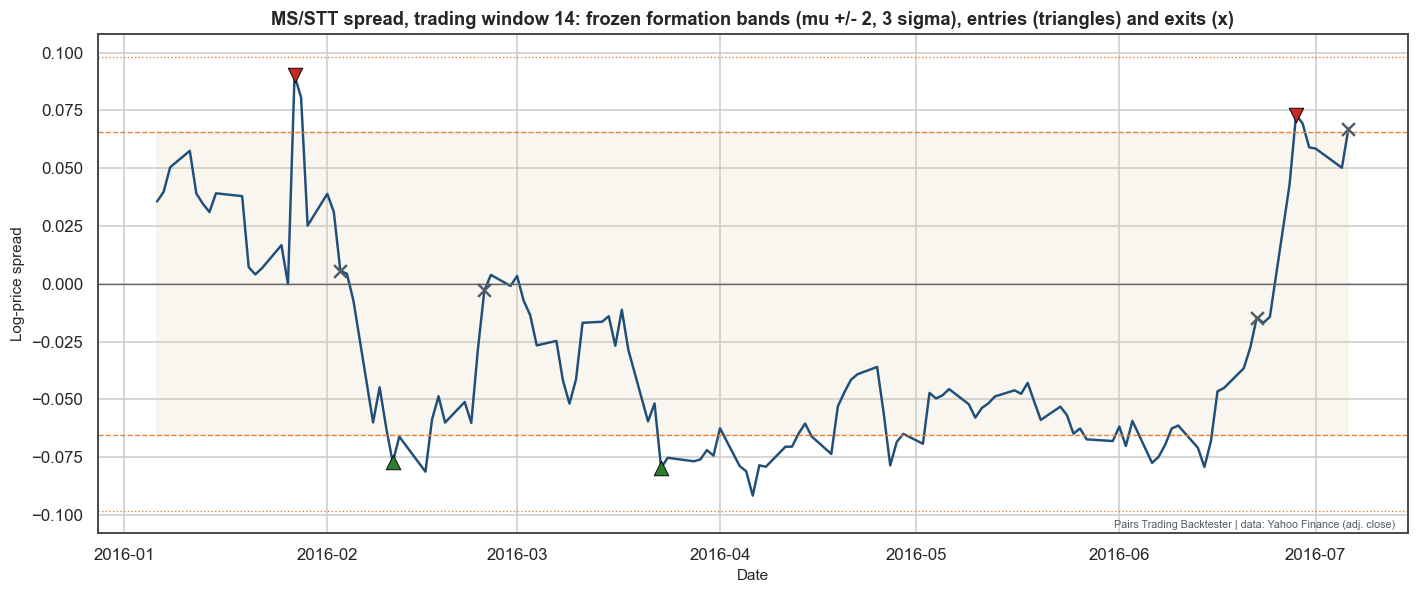

Bands come from the formation window that ENDED before 2016-01-06; nothing in this chart was fit on what it trades.


In [22]:
# Exhibit A: spread with formation bands and trade markers, most-traded window
# of the most-selected pair.
if not result.selections.empty and not result.trades.empty:
    _sc_trades = result.trades[result.trades["pair"] == SHOWCASE]
    _wid = (_sc_trades.groupby("window").size().idxmax()
            if not _sc_trades.empty else int(
                result.selections[result.selections["pair"] == SHOWCASE]["window"].iloc[0]))
    _row = result.selections[(result.selections["pair"] == SHOWCASE)
                             & (result.selections["window"] == _wid)].iloc[0]
    _a, _b = _row["leg_a"], _row["leg_b"]
    _tidx = OOS_IDX[(OOS_IDX >= _row["trade_start"]) & (OOS_IDX <= _row["trade_end"])]
    _spread = LOG_PX[_a].loc[_tidx] - _row["alpha"] - _row["beta"] * LOG_PX[_b].loc[_tidx]

    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.plot(_spread.index, _spread, color=PALETTE["strategy"], label="Spread (log)")
    for k, ls in [(0, "-"), (2, "--"), (-2, "--"), (3, ":"), (-3, ":")]:
        ax.axhline(_row["mu"] + k * _row["sigma"], color=PALETTE["accent"] if k else "#666",
                   ls=ls, lw=0.9)
    ax.fill_between(_spread.index, _row["mu"] - 2 * _row["sigma"],
                    _row["mu"] + 2 * _row["sigma"], color=PALETTE["band"], alpha=0.15)
    _wt = _sc_trades[_sc_trades["window"] == _wid]
    for _, t_ in _wt.iterrows():
        ax.scatter(t_["entry_date"], _spread.loc[t_["entry_date"]], marker="v" if
                   t_["side"] == "short_spread" else "^", s=90, zorder=5,
                   color=PALETTE["negative"] if t_["side"] == "short_spread"
                   else PALETTE["positive"], edgecolor="black", linewidth=0.6)
        ax.scatter(t_["exit_date"], _spread.loc[t_["exit_date"]], marker="x", s=70,
                   zorder=5, color=PALETTE["neutral"])
    ax.set_title(f"{SHOWCASE} spread, trading window {_wid}: frozen formation bands "
                 f"(mu +/- 2, 3 sigma), entries (triangles) and exits (x)")
    ax.set_ylabel("Log-price spread")
    ax.set_xlabel("Date")
    ax.annotate(SOURCE_NOTE, xy=(0.99, 0.01), xycoords="axes fraction",
                ha="right", fontsize=7, color=PALETTE["neutral"])
    plt.tight_layout()
    plt.show()
    print(f"Bands come from the formation window that ENDED before "
          f"{_tidx[0].date()}; nothing in this chart was fit on what it trades.")

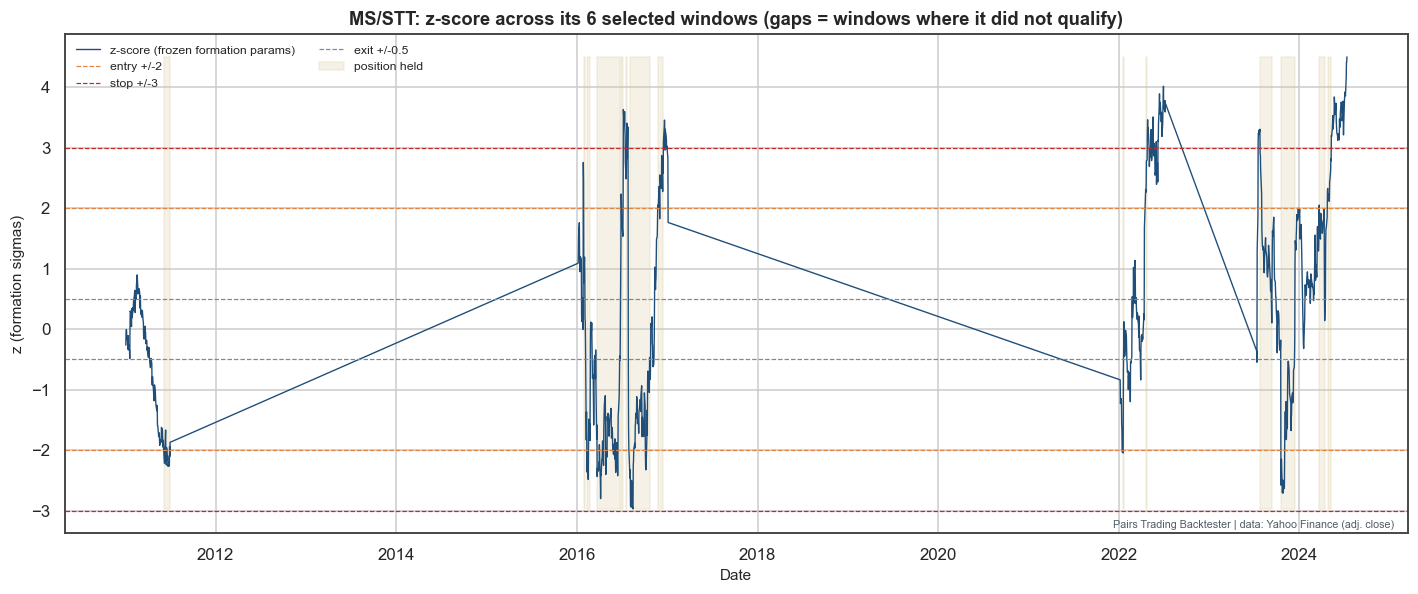

In [23]:
# Exhibit B: stitched z-score for the showcase pair across all its selected
# windows, with entry/exit/stop thresholds and held positions shaded.
if not result.selections.empty:
    _rows = result.selections[result.selections["pair"] == SHOWCASE]
    _z_parts, _u_parts = [], []
    for _, r_ in _rows.iterrows():
        _tidx = OOS_IDX[(OOS_IDX >= r_["trade_start"]) & (OOS_IDX <= r_["trade_end"])]
        _s = LOG_PX[r_["leg_a"]].loc[_tidx] - r_["alpha"] - r_["beta"] * LOG_PX[r_["leg_b"]].loc[_tidx]
        _z = (_s - r_["mu"]) / r_["sigma"]
        _z_parts.append(_z)
        _u_parts.append(zscore_positions(_z, CONFIG["ENTRY_Z"], CONFIG["EXIT_Z"],
                                         CONFIG["STOP_Z"]))
    z_stitched = pd.concat(_z_parts)
    u_stitched = pd.concat(_u_parts)

    fig, ax = plt.subplots(figsize=(13, 5.5))
    ax.plot(z_stitched.index, z_stitched, color=PALETTE["strategy"], lw=0.9,
            label="z-score (frozen formation params)")
    for lv, c, lb in [(CONFIG["ENTRY_Z"], PALETTE["accent"], "entry +/-2"),
                      (-CONFIG["ENTRY_Z"], PALETTE["accent"], None),
                      (CONFIG["STOP_Z"], PALETTE["negative"], "stop +/-3"),
                      (-CONFIG["STOP_Z"], PALETTE["negative"], None),
                      (CONFIG["EXIT_Z"], "#888", "exit +/-0.5"),
                      (-CONFIG["EXIT_Z"], "#888", None)]:
        ax.axhline(lv, color=c, ls="--", lw=0.8, label=lb)
    _held = u_stitched.shift(1).fillna(0.0)
    ax.fill_between(z_stitched.index, z_stitched.min(), z_stitched.max(),
                    where=_held != 0, color=PALETTE["band"], alpha=0.25,
                    label="position held")
    ax.set_title(f"{SHOWCASE}: z-score across its {len(_rows)} selected windows "
                 f"(gaps = windows where it did not qualify)")
    ax.set_ylabel("z (formation sigmas)")
    ax.set_xlabel("Date")
    ax.legend(loc="upper left", fontsize=8, ncol=2)
    ax.annotate(SOURCE_NOTE, xy=(0.99, 0.01), xycoords="axes fraction",
                ha="right", fontsize=7, color=PALETTE["neutral"])
    plt.tight_layout()
    plt.show()

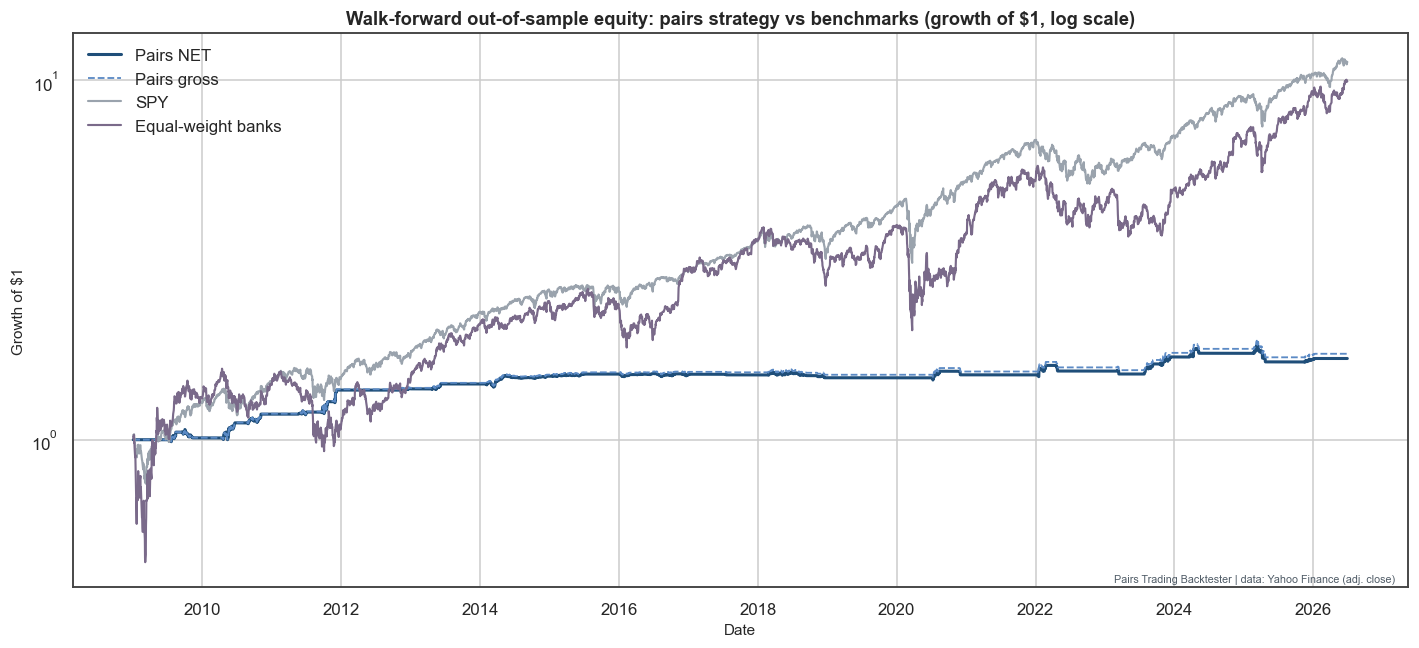

In [24]:
# Exhibit C: out-of-sample equity, gross and net, vs SPY and the equal-weight
# bank basket over the same days.
wealth = pd.DataFrame({
    "Pairs NET": (1 + result.net).cumprod(),
    "Pairs gross": (1 + result.gross).cumprod(),
    "SPY": (1 + BENCH_OOS).cumprod(),
    "Equal-weight banks": (1 + EW_OOS).cumprod(),
})
fig, ax = plt.subplots(figsize=(13, 6))
for col, c, lw, ls in [("Pairs NET", PALETTE["strategy"], 2.0, "-"),
                       ("Pairs gross", PALETTE["gross"], 1.2, "--"),
                       ("SPY", PALETTE["benchmark"], 1.4, "-"),
                       ("Equal-weight banks", PALETTE["basket"], 1.4, "-")]:
    ax.plot(wealth.index, wealth[col], color=c, lw=lw, ls=ls, label=col)
ax.set_yscale("log")
ax.set_title("Walk-forward out-of-sample equity: pairs strategy vs benchmarks "
             "(growth of $1, log scale)")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.legend(loc="upper left")
ax.annotate(SOURCE_NOTE, xy=(0.99, 0.01), xycoords="axes fraction",
            ha="right", fontsize=7, color=PALETTE["neutral"])
plt.tight_layout()
plt.show()
wealth.to_csv(os.path.join(OUTPUT_DIR, "pairs_equity_daily.csv"))

rolling EG:   0%|          | 0/210 [00:00<?, ?it/s]

rolling EG:   7%|▋         | 15/210 [00:00<00:01, 147.51it/s]

rolling EG:  15%|█▍        | 31/210 [00:00<00:01, 151.58it/s]

rolling EG:  22%|██▏       | 47/210 [00:00<00:01, 152.03it/s]

rolling EG:  30%|███       | 63/210 [00:00<00:00, 152.82it/s]

...

rolling EG:  76%|███████▌  | 159/210 [00:01<00:00, 153.92it/s]

rolling EG:  83%|████████▎ | 175/210 [00:01<00:00, 154.36it/s]

rolling EG:  91%|█████████ | 191/210 [00:01<00:00, 154.28it/s]

rolling EG:  99%|█████████▊| 207/210 [00:01<00:00, 154.45it/s]

rolling EG: 100%|██████████| 210/210 [00:01<00:00, 153.93it/s]

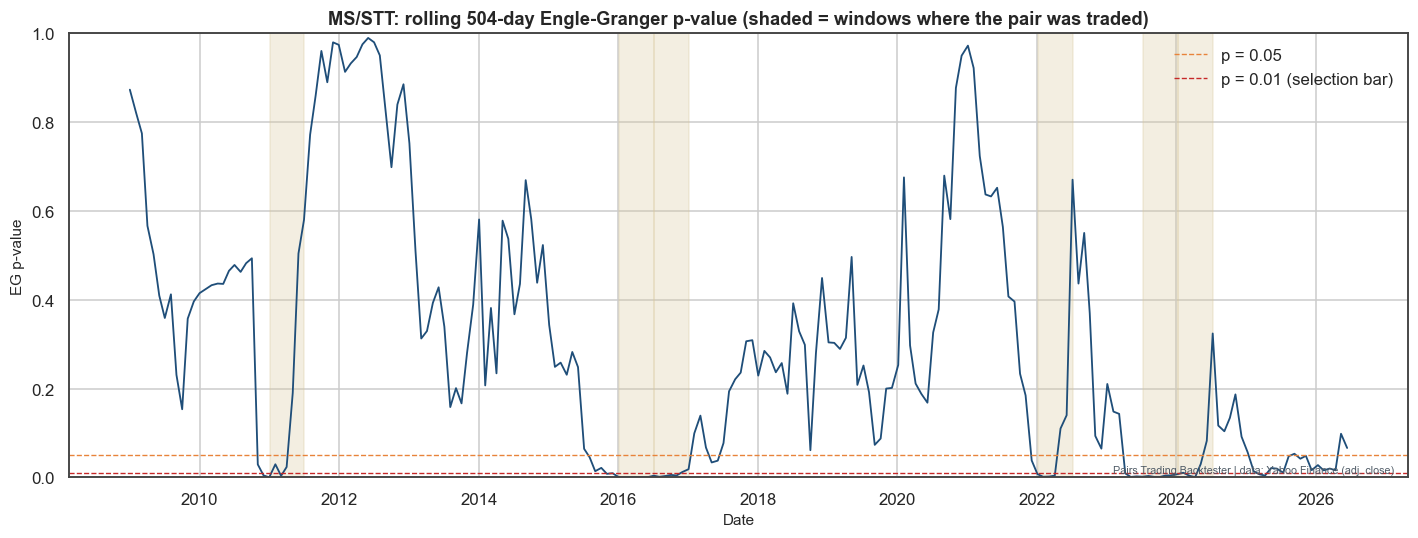

The relationship drifts in and out of significance. A pair chosen once and held forever would spend years trading a broken spread.


In [25]:
# Exhibit D: rolling Engle-Granger p-value for the showcase pair. Cointegration
# is episodic; this chart is why pairs must be re-selected every window.
if not result.selections.empty:
    _a, _b = SHOWCASE.split("/")
    _step, _F = 21, CONFIG["FORMATION_DAYS"]
    _ends = range(_F, len(LOG_PX), _step)
    roll_p = pd.Series(
        {LOG_PX.index[e - 1]: _eg_pvalue(LOG_PX[_a].iloc[e - _F:e],
                                         LOG_PX[_b].iloc[e - _F:e])
         for e in tqdm(_ends, desc="rolling EG")})

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(roll_p.index, roll_p, color=PALETTE["strategy"], lw=1.2)
    ax.axhline(0.05, color=PALETTE["accent"], ls="--", lw=0.9, label="p = 0.05")
    ax.axhline(CONFIG["EG_PVALUE_MAX"], color=PALETTE["negative"], ls="--", lw=0.9,
               label=f"p = {CONFIG['EG_PVALUE_MAX']} (selection bar)")
    _sel_windows = result.selections[result.selections["pair"] == SHOWCASE]
    for _, r_ in _sel_windows.iterrows():
        ax.axvspan(r_["trade_start"], r_["trade_end"], color=PALETTE["band"], alpha=0.3)
    ax.set_title(f"{SHOWCASE}: rolling {_F}-day Engle-Granger p-value "
                 f"(shaded = windows where the pair was traded)")
    ax.set_ylabel("EG p-value")
    ax.set_xlabel("Date")
    ax.set_ylim(0, 1)
    ax.legend(loc="upper right")
    ax.annotate(SOURCE_NOTE, xy=(0.99, 0.01), xycoords="axes fraction",
                ha="right", fontsize=7, color=PALETTE["neutral"])
    plt.tight_layout()
    plt.show()
    print("The relationship drifts in and out of significance. A pair chosen once "
          "and held forever would spend years trading a broken spread.")

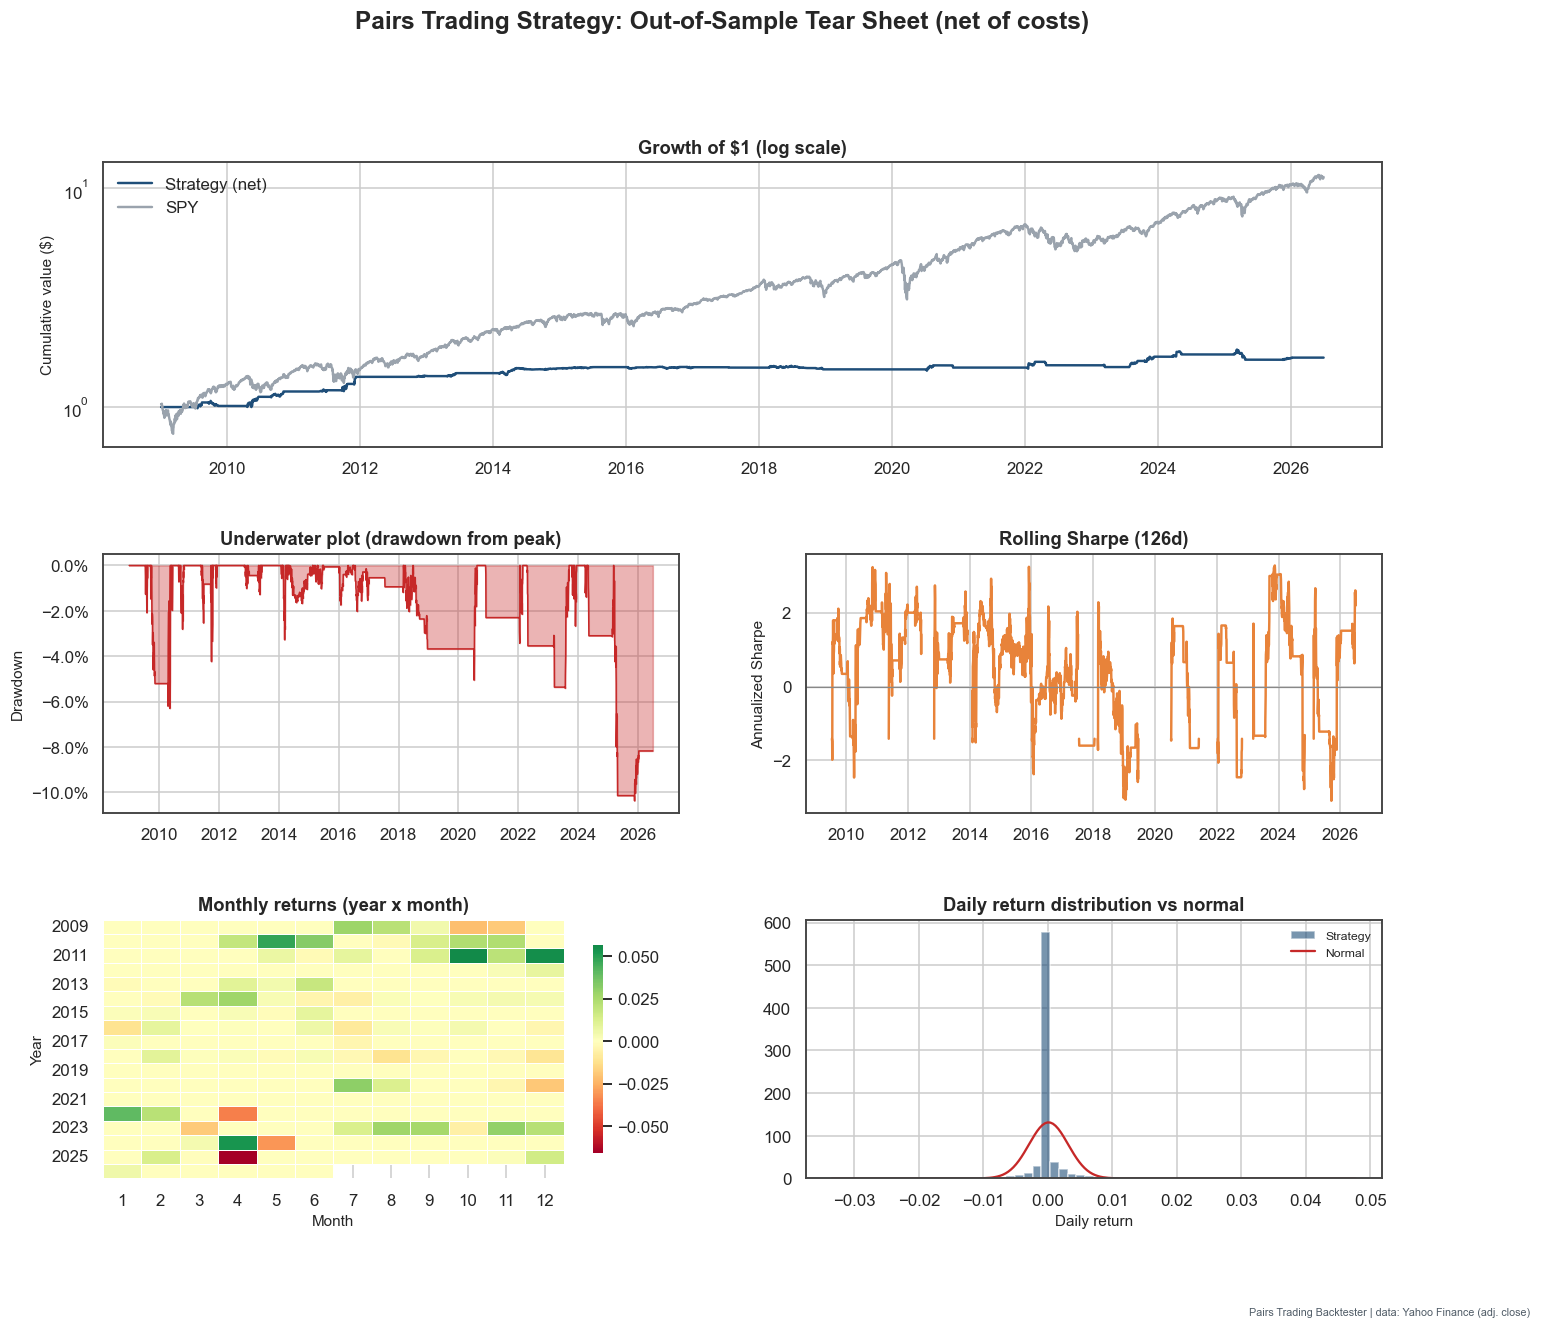

Saved: /Users/avinashmahadevan/Desktop/CC/quantprojects/outputs/pairs_tear_sheet.png


In [26]:
# Exhibit E: the house five-panel tear sheet for the NET strategy vs SPY.
def rolling_sharpe(returns: pd.Series, window: int) -> pd.Series:
    return (returns.rolling(window).mean() / returns.rolling(window).std(ddof=1)
            ) * np.sqrt(TRADING_DAYS_PER_YEAR)


def monthly_table(returns: pd.Series) -> pd.DataFrame:
    m = returns.resample(MONTH_END).apply(lambda s: float((1 + s).prod() - 1))
    df = m.to_frame("ret")
    df["Year"], df["Month"] = df.index.year, df.index.month
    return df.pivot(index="Year", columns="Month", values="ret")


def plot_tear_sheet(returns: pd.Series, benchmark: pd.Series, title: str,
                    outpath: str) -> None:
    """Five-panel house tear sheet: wealth, drawdown, rolling Sharpe, monthly
    heatmap, return distribution. Saves a PNG."""
    import matplotlib.gridspec as gridspec
    fig = plt.figure(figsize=(15, 12))
    gs = gridspec.GridSpec(3, 2, height_ratios=[1.1, 1.0, 1.0], hspace=0.40,
                           wspace=0.22)

    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot((1 + returns).cumprod(), color=PALETTE["strategy"], label="Strategy (net)")
    ax1.plot((1 + benchmark).cumprod(), color=PALETTE["benchmark"], label="SPY")
    ax1.set_yscale("log")
    ax1.set_title("Growth of $1 (log scale)")
    ax1.set_ylabel("Cumulative value ($)")
    ax1.legend(loc="upper left")

    ax2 = fig.add_subplot(gs[1, 0])
    dd = drawdown_series(returns)
    ax2.fill_between(dd.index, dd.values, 0, color=PALETTE["negative"], alpha=0.35)
    ax2.plot(dd.index, dd.values, color=PALETTE["negative"], lw=1.0)
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax2.set_title("Underwater plot (drawdown from peak)")
    ax2.set_ylabel("Drawdown")

    ax3 = fig.add_subplot(gs[1, 1])
    rs = rolling_sharpe(returns, CONFIG["ROLL_SHARPE_WIN"])
    ax3.plot(rs.index, rs.values, color=PALETTE["accent"])
    ax3.axhline(0, color="#888", lw=0.8)
    ax3.set_title(f"Rolling Sharpe ({CONFIG['ROLL_SHARPE_WIN']}d)")
    ax3.set_ylabel("Annualized Sharpe")

    ax4 = fig.add_subplot(gs[2, 0])
    sns.heatmap(monthly_table(returns), cmap="RdYlGn", center=0,
                cbar_kws={"shrink": 0.8}, linewidths=0.4, ax=ax4)
    ax4.set_title("Monthly returns (year x month)")

    ax5 = fig.add_subplot(gs[2, 1])
    r = returns.dropna()
    ax5.hist(r, bins=60, density=True, color=PALETTE["strategy"], alpha=0.6,
             label="Strategy")
    xs = np.linspace(r.min(), r.max(), 200)
    ax5.plot(xs, scistats.norm.pdf(xs, r.mean(), r.std(ddof=1)),
             color=PALETTE["negative"], lw=1.5, label="Normal")
    ax5.set_title("Daily return distribution vs normal")
    ax5.set_xlabel("Daily return")
    ax5.legend(fontsize=8)

    fig.suptitle(title, fontsize=16, weight="bold", y=0.995)
    fig.text(0.99, 0.005, SOURCE_NOTE, ha="right", va="bottom", fontsize=7,
             color=PALETTE["neutral"])
    fig.savefig(outpath, bbox_inches="tight", dpi=150)
    plt.show()


plot_tear_sheet(result.net, BENCH_OOS,
                "Pairs Trading Strategy: Out-of-Sample Tear Sheet (net of costs)",
                os.path.join(OUTPUT_DIR, "pairs_tear_sheet.png"))
print(f"Saved: {os.path.join(OUTPUT_DIR, 'pairs_tear_sheet.png')}")

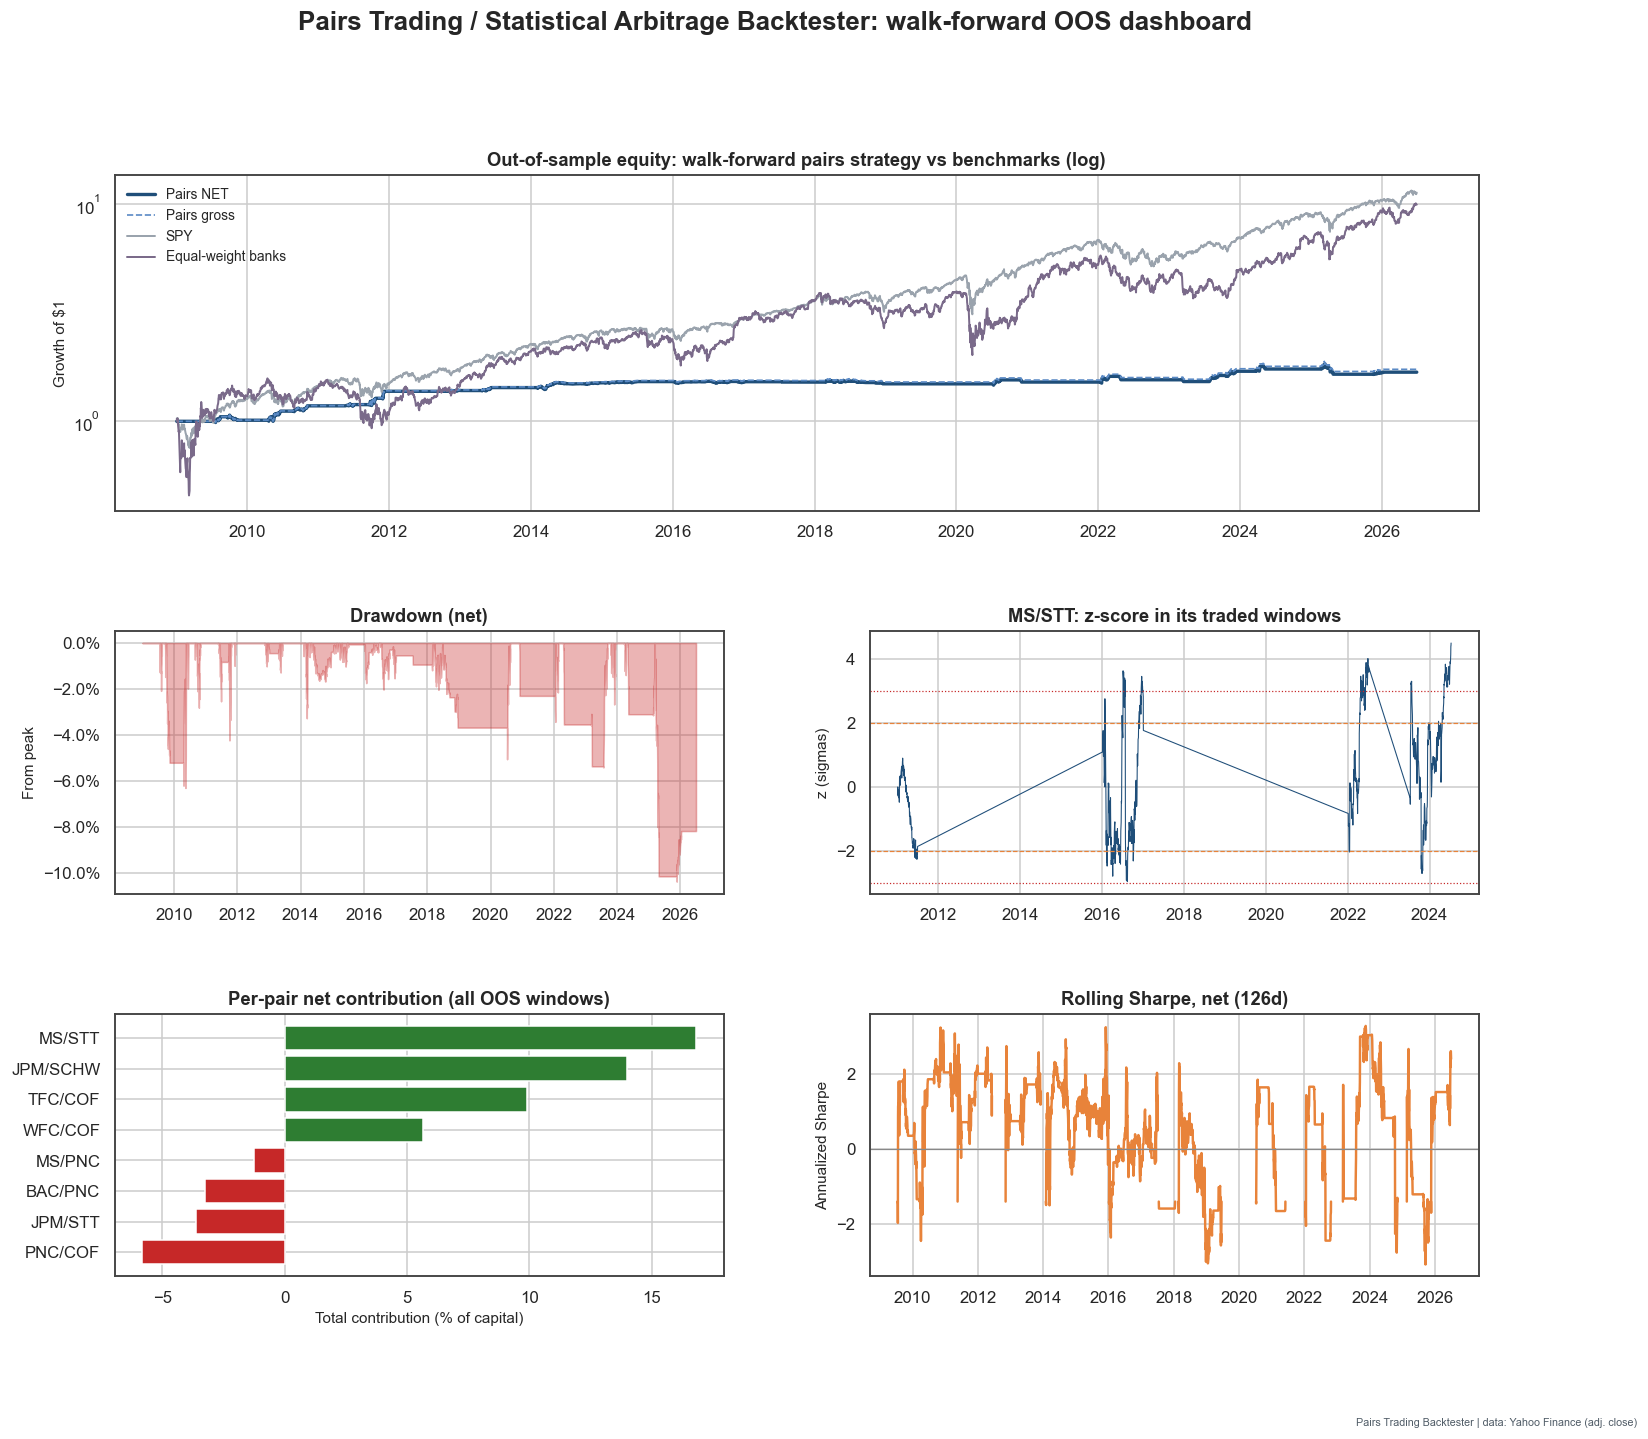

Saved hero exhibit: /Users/avinashmahadevan/Desktop/CC/quantprojects/outputs/pairs_hero_dashboard.png


In [27]:
# Exhibit F, the HERO: one dashboard that tells the whole story. Saved as the
# README screenshot.
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 13))
gs = gridspec.GridSpec(3, 2, height_ratios=[1.15, 0.9, 0.9], hspace=0.42, wspace=0.24)

axh1 = fig.add_subplot(gs[0, :])
for col, c, lw, ls in [("Pairs NET", PALETTE["strategy"], 2.2, "-"),
                       ("Pairs gross", PALETTE["gross"], 1.1, "--"),
                       ("SPY", PALETTE["benchmark"], 1.3, "-"),
                       ("Equal-weight banks", PALETTE["basket"], 1.3, "-")]:
    axh1.plot(wealth.index, wealth[col], color=c, lw=lw, ls=ls, label=col)
axh1.set_yscale("log")
axh1.set_title("Out-of-sample equity: walk-forward pairs strategy vs benchmarks (log)")
axh1.set_ylabel("Growth of $1")
axh1.legend(loc="upper left", fontsize=9)

axh2 = fig.add_subplot(gs[1, 0])
dd_net = drawdown_series(result.net)
axh2.fill_between(dd_net.index, dd_net.values, 0, color=PALETTE["negative"], alpha=0.35)
axh2.yaxis.set_major_formatter(PercentFormatter(1.0))
axh2.set_title("Drawdown (net)")
axh2.set_ylabel("From peak")

axh3 = fig.add_subplot(gs[1, 1])
if not result.selections.empty:
    axh3.plot(z_stitched.index, z_stitched, color=PALETTE["strategy"], lw=0.7)
    for lv in [CONFIG["ENTRY_Z"], -CONFIG["ENTRY_Z"]]:
        axh3.axhline(lv, color=PALETTE["accent"], ls="--", lw=0.8)
    for lv in [CONFIG["STOP_Z"], -CONFIG["STOP_Z"]]:
        axh3.axhline(lv, color=PALETTE["negative"], ls=":", lw=0.8)
    axh3.set_title(f"{SHOWCASE}: z-score in its traded windows")
    axh3.set_ylabel("z (sigmas)")

axh4 = fig.add_subplot(gs[2, 0])
if not result.pair_net.empty:
    contrib = result.pair_net.sum().sort_values()
    top = pd.concat([contrib.head(4), contrib.tail(4)])
    top = top[~top.index.duplicated()]
    colors = [PALETTE["negative"] if v < 0 else PALETTE["positive"] for v in top]
    axh4.barh(top.index, top.values * 100, color=colors)
    axh4.set_title("Per-pair net contribution (all OOS windows)")
    axh4.set_xlabel("Total contribution (% of capital)")

axh5 = fig.add_subplot(gs[2, 1])
rs_net = rolling_sharpe(result.net, CONFIG["ROLL_SHARPE_WIN"])
axh5.plot(rs_net.index, rs_net.values, color=PALETTE["accent"])
axh5.axhline(0, color="#888", lw=0.8)
axh5.set_title(f"Rolling Sharpe, net ({CONFIG['ROLL_SHARPE_WIN']}d)")
axh5.set_ylabel("Annualized Sharpe")

fig.suptitle("Pairs Trading / Statistical Arbitrage Backtester: "
             "walk-forward OOS dashboard", fontsize=17, weight="bold", y=0.995)
fig.text(0.99, 0.004, SOURCE_NOTE, ha="right", va="bottom", fontsize=7,
         color=PALETTE["neutral"])
HERO_PATH = os.path.join(OUTPUT_DIR, "pairs_hero_dashboard.png")
fig.savefig(HERO_PATH, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved hero exhibit: {HERO_PATH}")

In [28]:
# Interactive plotly dashboard, exported as standalone HTML (survives on GitHub
# via nbviewer/download; a static PNG is also attempted via kaleido).
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pfig = make_subplots(
    rows=2, cols=2, specs=[[{"colspan": 2}, None], [{}, {}]],
    subplot_titles=("Growth of $1 (log)", "Drawdown (net)", "Rolling Sharpe (net)"),
    vertical_spacing=0.12)
for col, c in [("Pairs NET", PALETTE["strategy"]), ("Pairs gross", PALETTE["gross"]),
               ("SPY", PALETTE["benchmark"]),
               ("Equal-weight banks", PALETTE["basket"])]:
    pfig.add_trace(go.Scatter(x=wealth.index, y=wealth[col], name=col,
                              line=dict(color=c)), row=1, col=1)
pfig.update_yaxes(type="log", row=1, col=1)
pfig.add_trace(go.Scatter(x=dd_net.index, y=dd_net, fill="tozeroy", name="Drawdown",
                          line=dict(color=PALETTE["negative"]), showlegend=False),
               row=2, col=1)
pfig.add_trace(go.Scatter(x=rs_net.index, y=rs_net, name="Rolling Sharpe",
                          line=dict(color=PALETTE["accent"]), showlegend=False),
               row=2, col=2)
pfig.update_layout(title="Pairs Trading Backtester: interactive OOS dashboard",
                   template="plotly_white", height=750, width=1150)

html_path = os.path.join(OUTPUT_DIR, "pairs_interactive_dashboard.html")
pfig.write_html(html_path, include_plotlyjs=True)
print(f"Saved interactive dashboard: {html_path}")
try:
    pfig.write_image(os.path.join(OUTPUT_DIR, "pairs_interactive_dashboard.png"),
                     scale=2)
    print("Static PNG of the dashboard saved (kaleido).")
except Exception as exc:
    print(f"kaleido PNG export skipped ({type(exc).__name__}); HTML export is the "
          f"canonical interactive artifact.")

if not result.trades.empty:
    result.trades.to_csv(os.path.join(OUTPUT_DIR, "pairs_trades.csv"), index=False)
if not result.selections.empty:
    result.selections.to_csv(os.path.join(OUTPUT_DIR, "pairs_selections.csv"),
                             index=False)
print("Saved: trade ledger and per-window selections to outputs/.")

Saved interactive dashboard: /Users/avinashmahadevan/Desktop/CC/quantprojects/outputs/pairs_interactive_dashboard.html


Static PNG of the dashboard saved (kaleido).
Saved: trade ledger and per-window selections to outputs/.


<a id="sec-15"></a>
## 15. Robustness and Sensitivity

A result that only exists at entry 2.0 / exit 0.5 / 24-month formation is a curve-fit, not a strategy. Four stress tests: (1) a grid over entry/exit thresholds, where a healthy strategy shows a plateau of similar Sharpes, not one lucky island; (2) a transaction-cost sweep, which answers the practical question "at what per-leg cost does the edge disappear?"; (3) alternative formation-window lengths, trading off estimation noise (short windows) against staleness (long windows); (4) a regime breakdown across three very different market environments. The threshold grid re-uses the cached cointegration screens, so only signals and accounting are recomputed.

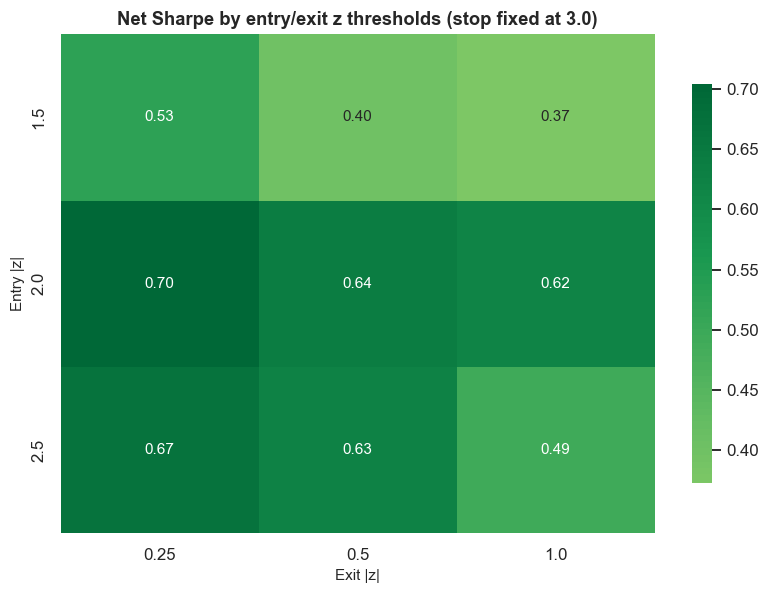

Base configuration (entry 2.0, exit 0.5): net Sharpe 0.64. Read the surface, not the best cell: a plateau means the effect is real; one bright cell means luck.


In [29]:
grid_rows = []
for e_z in [1.5, 2.0, 2.5]:
    for x_z in [0.25, 0.5, 1.0]:
        cfg_g = dict(CONFIG, ENTRY_Z=e_z, EXIT_Z=x_z)
        r_g = run_walk_forward(PRICES, cfg_g, SCREENS, quiet=True)
        grid_rows.append({"entry": e_z, "exit": x_z,
                          "net_sharpe": _quick_sharpe(r_g.net),
                          "net_cagr": _quick_cagr(r_g.net),
                          "trades": len(r_g.trades)})
grid_df = pd.DataFrame(grid_rows)
grid_sharpe = grid_df.pivot(index="entry", columns="exit", values="net_sharpe")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(grid_sharpe, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Net Sharpe by entry/exit z thresholds (stop fixed at 3.0)")
ax.set_xlabel("Exit |z|")
ax.set_ylabel("Entry |z|")
plt.tight_layout()
plt.show()
grid_df.to_csv(os.path.join(OUTPUT_DIR, "pairs_robustness_thresholds.csv"), index=False)
base_cell = grid_df[(grid_df["entry"] == CONFIG["ENTRY_Z"])
                    & (grid_df["exit"] == CONFIG["EXIT_Z"])].iloc[0]
print(f"Base configuration (entry {CONFIG['ENTRY_Z']}, exit {CONFIG['EXIT_Z']}): "
      f"net Sharpe {base_cell['net_sharpe']:.2f}. Read the surface, not the best cell: "
      f"a plateau means the effect is real; one bright cell means luck.")

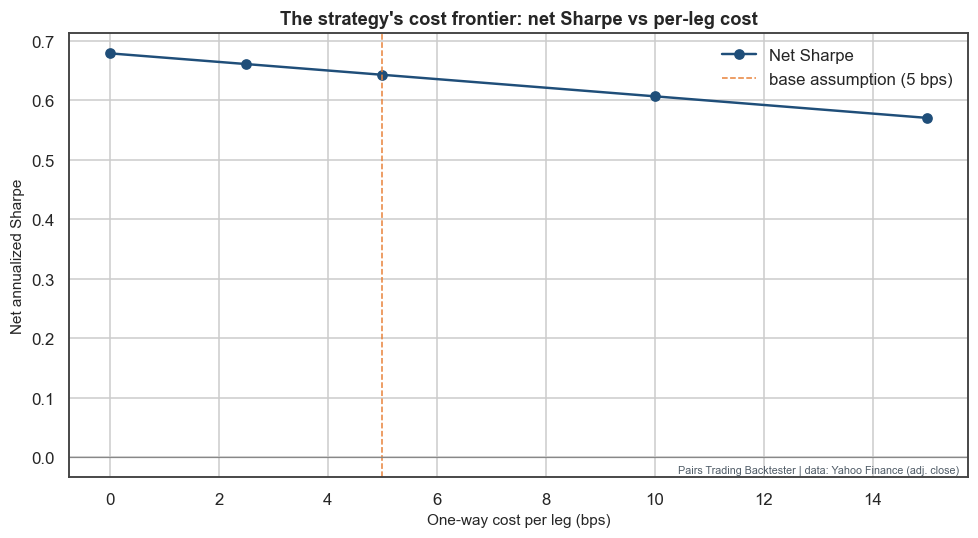

,cost_bps_per_leg,net_sharpe,net_cagr
0,0.0,0.679,0.032
1,2.5,0.661,0.031
2,5.0,0.643,0.030
3,10.0,0.606,0.028
4,15.0,0.570,0.027


Every round trip is four legs, so per-leg costs bite four times. This chart is why cost honesty is not optional in pairs trading.


In [30]:
# Cost sweep: net = gross - turnover x cost, recomputed from the stored base run.
cost_rows = []
for c_bps in [0.0, 2.5, 5.0, 10.0, 15.0]:
    net_c = result.gross - result.turnover * (c_bps / 1e4)
    cost_rows.append({"cost_bps_per_leg": c_bps, "net_sharpe": _quick_sharpe(net_c),
                      "net_cagr": _quick_cagr(net_c)})
cost_df = pd.DataFrame(cost_rows)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cost_df["cost_bps_per_leg"], cost_df["net_sharpe"], marker="o",
        color=PALETTE["strategy"], label="Net Sharpe")
ax.axvline(CONFIG["COST_PER_LEG_BPS"], color=PALETTE["accent"], ls="--", lw=1.0,
           label=f"base assumption ({CONFIG['COST_PER_LEG_BPS']:.0f} bps)")
ax.axhline(0, color="#888", lw=0.8)
ax.set_title("The strategy's cost frontier: net Sharpe vs per-leg cost")
ax.set_xlabel("One-way cost per leg (bps)")
ax.set_ylabel("Net annualized Sharpe")
ax.legend()
ax.annotate(SOURCE_NOTE, xy=(0.99, 0.01), xycoords="axes fraction",
            ha="right", fontsize=7, color=PALETTE["neutral"])
plt.tight_layout()
plt.show()
cost_df.to_csv(os.path.join(OUTPUT_DIR, "pairs_robustness_costs.csv"), index=False)
display(cost_df.round(3))
print("Every round trip is four legs, so per-leg costs bite four times. This chart "
      "is why cost honesty is not optional in pairs trading.")

In [31]:
# Formation-window sensitivity: 12, 24 (base), 36 months.
form_rows = []
for f_days, label in [(252, "12m"), (CONFIG["FORMATION_DAYS"], "24m (base)"),
                      (756, "36m")]:
    cfg_f = dict(CONFIG, FORMATION_DAYS=f_days)
    r_f = (result if f_days == CONFIG["FORMATION_DAYS"]
           else run_walk_forward(PRICES, cfg_f, SCREENS, quiet=True))
    sel_per_win = (len(r_f.selections) / len(r_f.windows)) if len(r_f.windows) else 0.0
    form_rows.append({"formation": label, "windows": len(r_f.windows),
                      "avg pairs/window": sel_per_win, "trades": len(r_f.trades),
                      "net_sharpe": _quick_sharpe(r_f.net),
                      "net_cagr": _quick_cagr(r_f.net),
                      "max_dd": _quick_maxdd(r_f.net)})
form_df = pd.DataFrame(form_rows).set_index("formation")
display(form_df.round(3))
form_df.to_csv(os.path.join(OUTPUT_DIR, "pairs_robustness_formation.csv"))
print("Short formation windows react faster but estimate beta and the half-life "
      "noisily; long windows average over regimes that no longer exist. The base "
      "24m is a compromise, not an optimum.")

,windows,avg pairs/window,trades,net_sharpe,net_cagr,max_dd
formation,,,,,,
12m,37,1.081,47,0.088,0.002,-0.164
24m (base),35,1.257,57,0.643,0.030,-0.104
36m,33,1.879,45,-0.013,-0.001,-0.076


Short formation windows react faster but estimate beta and the half-life noisily; long windows average over regimes that no longer exist. The base 24m is a compromise, not an optimum.


In [32]:
# Regime breakdown of the base run: crisis recovery, QE bull, COVID and rate shock.
regimes = {
    "2009-2012 (GFC recovery)": ("2009-01-01", "2012-12-31"),
    "2013-2019 (QE bull)": ("2013-01-01", "2019-12-31"),
    "2020-2026 (COVID + rate shock)": ("2020-01-01", "2026-06-30"),
}
reg_rows = []
for name, (a, b) in regimes.items():
    seg = result.net.loc[a:b]
    if len(seg) < 60:
        continue
    seg_spy = BENCH_OOS.loc[a:b]
    active = float((result.gross.loc[a:b] != 0).mean())
    reg_rows.append({"regime": name, "days": len(seg),
                     "net_sharpe": _quick_sharpe(seg), "net_cagr": _quick_cagr(seg),
                     "max_dd": _quick_maxdd(seg), "days_active": active,
                     "spy_sharpe": _quick_sharpe(seg_spy)})
reg_df = pd.DataFrame(reg_rows).set_index("regime")
display(reg_df.round(3))
print("Pairs edges are regime-dependent: the literature (Gatev et al. 2006; Do and "
      "Faff 2010) documents decay as the trade crowded. Where the edge is "
      "concentrated in this sample is visible above; Section 16 discusses why.")

,days,net_sharpe,net_cagr,max_dd,days_active,spy_sharpe
regime,,,,,,
2009-2012 (GFC recovery),1006,1.145,0.086,-0.063,0.247,0.758
2013-2019 (QE bull),1762,0.406,0.010,-0.037,0.405,1.128
2020-2026 (COVID + rate shock),1630,0.431,0.019,-0.104,0.152,0.807


Pairs edges are regime-dependent: the literature (Gatev et al. 2006; Do and Faff 2010) documents decay as the trade crowded. Where the edge is concentrated in this sample is visible above; Section 16 discusses why.


<a id="sec-16"></a>
## 16. Limitations and Assumptions

An honest list. Several of these bias the backtest optimistic, and none of them are fixable with the free data used here.

1. **Survivorship bias, by name.** The universe is 2026's surviving large-cap financials. Lehman Brothers, Wachovia, Washington Mutual, National City, and Countrywide are absent because they died or were absorbed in 2008-2009. A pair containing Lehman would have produced a spread that never reverted; a cointegration screen run in 2007 could easily have selected one. The 2009-2012 segment of this backtest is therefore flattered by construction, and the true 2008-vintage risk of this strategy is understated.
2. **The 2008 short-sale ban.** The SEC banned short sales in roughly 800 financial stocks from September 19 to October 8, 2008, and borrow remained scarce and expensive well into 2009. A strategy that shorts banks could not have been executed as modeled through that stretch. The first trading window here starts in early 2009, which limits direct overlap, but any earlier extension of this backtest would be fiction.
3. **No borrow costs or short availability.** Every short leg is assumed free to borrow at zero fee, and short proceeds earn nothing. Hard-to-borrow fees on stressed financials can exceed the entire spread edge.
4. **Close-to-close execution.** Signals fire at the close and fill at the close. Gaps matter: a spread that gaps from 2.9 to 4 sigma overnight fills at 4, not 3; the stop is a valve, not a guarantee.
5. **Frozen parameters within each window.** Beta, mu, and sigma are held fixed for six months. A relationship that drifts mid-window is traded on stale parameters until the next re-selection; a Kalman filter (Section 17) is the standard upgrade.
6. **Multiple testing is mitigated, not eliminated.** Thousands of hypotheses are examined over the full run. The p < 0.01 bar, half-life and beta filters, and per-window re-qualification reduce false discovery; they cannot zero it.
7. **Capacity and impact.** 5 bps per leg is realistic for small size in these very liquid names. At institutional size, market impact grows with participation, and crowding by other stat-arb desks erodes the edge itself (Do and Faff 2010 document exactly this decay).
8. **Not point-in-time data.** Yahoo's adjusted prices are restated by later splits and dividends; the prices used for 2009 decisions are not the prices a 2009 trader saw on screen.
9. **Single-sector concentration.** All pairs share the bank factor. A systemic event (March 2020, the March 2023 regional-bank stress) hits every spread at once, so the diversification across five pairs is thinner than it looks.
10. **Forced window-end closes** add turnover and costs that a production system with parameter continuity would avoid.
11. **Hindsight in the configuration.** Entry 2 / exit 0.5 / stop 3 and the 24-month window are the literature's standard settings, not fitted here, and Section 15 varies them honestly; still, "standard in the literature" itself encodes decades of collective hindsight.
12. **Zero interest on idle cash.** Reserved capital earns nothing, which understates net returns in high-rate years; this one is conservative rather than optimistic.

<a id="sec-17"></a>
## 17. Conclusion, Extensions and Deliverables

**What this project demonstrates.** Cointegration, not correlation, is the property that makes a spread tradable, and the difference is visible in this very dataset. The walk-forward formation/trading architecture is the strategy's real safety mechanism: the cautionary comparison in Section 12.1 shows that a circular backtest trades five relationships the honest funnel rejects outright and that nobody could have named in advance, with a drawdown half again worse; the size of a selection leak is unknowable before you commit to it, which is exactly why the architecture, not luck, has to prevent it. The OU half-life works as an economic filter, not just a statistical one: it screens out spreads too fast to trade after costs and too slow to monetize within a window. Costs bite four legs at a time, and the cost frontier in Section 15 shows how quickly a paper edge dies as frictions rise. Finally, market neutrality is verified, not assumed: the SPY beta and its t-statistic are reported in Section 12.2.

**Extensions toward institutional grade:**

1. **Johansen / VECM baskets.** Replace pairwise Engle-Granger with Johansen rank tests over small clusters, trading 3-5 asset baskets whose cointegrating vectors are estimated symmetrically.
2. **Kalman-filter hedge ratios.** Let beta and mu evolve daily as a state-space model instead of freezing them per window; this removes the staleness in limitation 5 and typically smooths the spread.
3. **OU-optimal thresholds.** Derive entry/exit bands per pair from the fitted OU parameters (Bertram 2010; Avellaneda and Lee 2010) instead of one-size-fits-all 2 / 0.5 / 3.
4. **Realistic short-side frictions.** Add per-name borrow fees, short-availability flags, and the 2008 ban as a hard constraint; re-run the GFC-era windows and measure how much of the early-period P&L survives.
5. **Wider universe with clustering and regime gating.** Screen a few hundred liquid names, cluster by statistical similarity before pair formation, and gate new entries on a stress indicator (VIX, credit spreads) so the book stops adding risk when spreads blow out together.

**Deliverables produced by this notebook** (all in `outputs/`):

- `pairs_hero_dashboard.png` - the recruiter-facing summary exhibit
- `pairs_tear_sheet.png` - the house five-panel tear sheet, net of costs
- `pairs_interactive_dashboard.html` - standalone interactive plotly dashboard
- `pairs_equity_daily.csv` - daily gross/net/benchmark wealth curves
- `pairs_trades.csv` - the full round-trip ledger with exit reasons
- `pairs_selections.csv` - every (window, pair) selection with parameters
- `pairs_summary_metrics.csv` - the headline metrics table
- `pairs_robustness_thresholds.csv`, `pairs_robustness_costs.csv`, `pairs_robustness_formation.csv` - sensitivity tables

<a id="sec-18"></a>
## 18. References

**Papers and books**

- Engle, R. F., and C. W. J. Granger (1987). "Co-integration and Error Correction: Representation, Estimation, and Testing." *Econometrica* 55(2), 251-276.
- MacKinnon, J. G. (1994, 2010). "Critical Values for Cointegration Tests." Queen's Economics Department Working Paper 1227.
- Johansen, S. (1988). "Statistical Analysis of Cointegration Vectors." *Journal of Economic Dynamics and Control* 12, 231-254.
- Gatev, E., W. N. Goetzmann, and K. G. Rouwenhorst (2006). "Pairs Trading: Performance of a Relative-Value Arbitrage Rule." *Review of Financial Studies* 19(3), 797-827.
- Do, B., and R. Faff (2010). "Does Simple Pairs Trading Still Work?" *Financial Analysts Journal* 66(4), 83-95.
- Avellaneda, M., and J.-H. Lee (2010). "Statistical Arbitrage in the US Equities Market." *Quantitative Finance* 10(7), 761-782.
- Vidyamurthy, G. (2004). *Pairs Trading: Quantitative Methods and Analysis.* Wiley.
- Bertram, W. K. (2010). "Analytic Solutions for Optimal Statistical Arbitrage Trading." *Physica A* 389(11), 2234-2243.
- Lo, A. W. (2002). "The Statistics of Sharpe Ratios." *Financial Analysts Journal* 58(4), 36-52.
- Newey, W. K., and K. D. West (1987). "A Simple, Positive Semi-definite, Heteroskedasticity and Autocorrelation Consistent Covariance Matrix." *Econometrica* 55(3), 703-708.
- Lopez de Prado, M. (2018). *Advances in Financial Machine Learning.* Wiley. (Walk-forward and purged cross-validation discipline.)

**Data and libraries**

- Yahoo Finance daily adjusted prices via `yfinance`.
- `pandas`, `numpy`, `statsmodels` (Engle-Granger `coint`, OLS, HAC covariance), `scipy`, `matplotlib`, `seaborn`, `plotly`, `tqdm`.

<a id="sec-19"></a>
## 19. README and Resume Bullets

Ready-to-paste GitHub README for a standalone repository, followed by resume bullets.

```markdown
# Pairs Trading Statistical Arbitrage Backtester

Walk-forward pairs trading on 12 large-cap US financials (2007-2026): Engle-Granger
cointegration screening, Ornstein-Uhlenbeck half-life filtering, z-score long-short
signals, and per-leg transaction costs. Every reported number is out of sample.

![Hero dashboard](outputs/pairs_hero_dashboard.png)

## What it does

- Screens all 66 pairs of a 12-stock bank universe for cointegration on a rolling
  24-month formation window (Engle-Granger, p < 0.01 to control 66-way multiple
  testing), with hedge ratios estimated by OLS on log prices.
- Filters candidates by OU half-life (5-60 days) and hedge-ratio sanity (0.4-2.5).
- Trades the next 6 months out of sample with frozen parameters: enter at |z| > 2,
  exit at |z| < 0.5, stop with lockout at |z| > 3, forced flat at window end.
- Charges 5 bps per leg (four legs per round trip) and reports gross and net.
- Audits itself: structural look-ahead checks, parameter-provenance verification,
  Newey-West significance, Lo Sharpe confidence interval, and a beta-to-SPY
  regression that verifies market neutrality empirically.

## Data

Yahoo Finance daily adjusted closes via yfinance (free, no key). JPM, BAC, WFC, C,
GS, MS, USB, PNC, TFC, SCHW, COF, STT, benchmark SPY. The universe is survivorship
biased (no Lehman, no Wachovia); the README of record for that caveat is Section 16
of the notebook.

## How to run

Open the notebook in Colab (badge at the top) and Run All; no API keys needed.
Offline/CI runs: set QUANT_OFFLINE=1 to use the deterministic synthetic dataset
with planted cointegration. Local: pip install yfinance pandas numpy statsmodels
scipy matplotlib seaborn plotly tqdm, then run the notebook top to bottom.

## Results highlight

Walk-forward out of sample, January 2009 to June 2026, net of 5 bps per leg:
3.0% CAGR at 4.8% annualized volatility, Sharpe 0.64 (Lo 95% CI [0.17, 1.11]),
Newey-West t = 2.81, SPY beta -0.01 (t = -0.75), annualized alpha 3.3%
(t = 2.99), max drawdown -10.4% (SPY over the same days: -33.7%). 57 round
trips, 59.6% win rate, median holding 18 days. The edge is statistically
significant but modest, and concentrated in 2009-2012; the notebook reports
that decay rather than hiding it.

## Limitations

Survivorship-biased universe, no borrow fees or short-availability constraints
(materially wrong for financials in late 2008), close-to-close fills, and Yahoo
prices are not point in time. Section 16 of the notebook has the full list.
```

**Resume bullets** (quantified, action verb + method + tools + measurable result):

- Built a walk-forward pairs trading backtester in Python (pandas, statsmodels) that screens 66 bank-stock pairs for cointegration in rolling 24-month formation windows and trades z-score signals strictly out of sample over 2009-2026, producing a market-neutral return stream with a net Sharpe of 0.64 (Newey-West t = 2.8) and a SPY beta of -0.01.
- Engineered leak-free validation with structural look-ahead audits, parameter-provenance checks, and multiple-testing controls across 2,310 cointegration tests, and modeled per-leg transaction costs on 57 round trips (four legs each), reporting gross and net results side by side.
- Quantified strategy fragility through entry/exit threshold grids, cost sweeps to 15 bps per leg, formation-window sensitivity, and regime breakdowns, documenting the post-2012 decay of the pairs edge (Sharpe 1.15 in 2009-2012 versus roughly 0.4 after) in line with published crowding evidence.

<a id="sec-20"></a>
## 20. Final Summary

This notebook built a complete, self-auditing pairs trading research pipeline: cointegration screening with multiple-testing control, OU half-life economics, walk-forward out-of-sample execution with frozen formation parameters, per-leg cost accounting, and empirical verification of market neutrality. The result is a statistically significant but modest market-neutral edge (net Sharpe 0.64, SPY beta -0.01, max drawdown -10.4%), concentrated in 2009-2012 and reported with its decay, its cost frontier, and its configuration sensitivity in full view. The cautionary in-sample comparison demonstrates the circularity this design exists to prevent.

**Strongest resume bullet:** Built a walk-forward pairs trading backtester in Python (pandas, statsmodels) that screens 66 bank-stock pairs for cointegration in rolling 24-month formation windows and trades z-score signals strictly out of sample over 2009-2026, producing a market-neutral return stream with a net Sharpe of 0.64 (Newey-West t = 2.8) and a SPY beta of -0.01.